# Sales Forecasting Using Time Series Models with Exogenous Logistics Variables

## 1. Introdução e Contexto
Este projeto apresenta o desenvolvimento de uma estrutura técnica de Sales and Operations Planning (S&OP) aplicada ao setor industrial. O objetivo é a integração de bases de dados heterogêneas para otimizar o processo de tomada de decisão na cadeia de suprimentos, utilizando modelagem avançada de séries temporais para o planejamento de demanda.

### Objetivos do Projeto:

1. Pipeline de Dados (ETL): Unificação e normalização de dados históricos de demanda (formato .xlsx) e níveis de inventário (formato .csv).

2. Engenharia de Variáveis (Feature Engineering): Cálculo da "Pressão de Inventário", definida pela variância entre o saldo físico real e os parâmetros de política de estoque (Estoque Mínimo e Máximo).

3. Análise Preditiva de Séries Temporais: Implementação e comparação de modelos estatísticos e estocásticos (ARIMA, SARIMAX, Decomposição STL) para projeção de demanda futura.

4. Consolidado de Apoio à Decisão: Geração de um re-forecast estratégico para alinhamento entre as áreas de produção, vendas e logística.

###  Bases de Dados Utilizadas:
* `base_completa_vendas_orcamento`: Contém o histórico de demanda realizada e as metas planejadas.
* `estoque_diario_cd_2022`: Posição diária e políticas de estoque do nó central de distribuição.
* `estoque_diario_rede_2022`: Posição diária e parâmetros de estoque da rede capilarizada de unidades de consumo.

# 0. Configuração do Ambiente e Dependências

Nesta etapa inicial, preparamos o ambiente de execução e importamos o ecossistema de bibliotecas necessárias para o processamento de grandes volumes de dados e modelagem estocástica.

### Bibliotecas Utilizadas:

* **Manipulação e Cálculo (`Pandas` & `NumPy`):** Essenciais para a estruturação dos *DataFrames*, limpeza de dados (ETL) e implementação das fórmulas de **Pressão de Inventário** e normalização decimal.
* **Análise Estatística e Preditiva (`Statsmodels`):** O "motor" principal do projeto. Utilizado para:
    * **Decomposição de Séries:** Identificação de tendência e sazonalidade.
    * **Modelos de Suavização:** Implementação de *Simple Exponential Smoothing*, *Holt* e *Holt-Winters*.
    * **Modelagem Avançada:** Execução do **SARIMAX** e suporte ao **STL** (*Seasonal-Trend decomposition using LOESS*).
* **Automação Preditiva (`pmdarima`):** Utilizada para o algoritmo `auto_arima`, que automatiza a busca exaustiva pelos melhores hiperparâmetros $(p, d, q) \times (P, D, Q, m)$, garantindo a minimização do critério de informação (AIC).
* **Visualização de Dados (`Matplotlib`):** Customização de dashboards técnicos, gráficos de auditoria e plotagem de resíduos estatísticos com suporte a *patches* e formatação de datas dinâmica.
* **Interface e Armazenamento (`Google Colab` & `Drive`):** Ambiente de desenvolvimento em nuvem que permite o consumo escalonável de recursos computacionais e integração com o repositório de dados.

### Configurações Globais do Experimento:
* **Filtragem de Alertas:** Supressão de avisos de depreciação para garantir a legibilidade do relatório técnico.
* **Padronização Visual:** Definição de estilos gráficos (*whitegrid*) e dimensões de plotagem para conformidade com padrões acadêmicos de apresentação de dados.

In [44]:
# 0.1. INSTALAÇÃO DE DEPENDÊNCIAS (Bibliotecas não nativas do Colab)

print("Instalando dependências... (isso pode levar alguns segundos)")
!pip install pmdarima -q
!pip install statsmodels --upgrade -q

# 0.2. IMPORTAÇÃO DE BIBLIOTECAS

import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ferramentas de Séries Temporais
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import pmdarima as pm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.forecasting.stl import STLForecast

# Ferramentas de Gráficos
import matplotlib.patches as patches

# Configurações do Google Colab e Interface
from google.colab import drive, files
from IPython.display import display

# 0.3. CONFIGURAÇÕES GLOBAIS

warnings.filterwarnings("ignore")

# Configuração visual dos gráficos
plt.rcParams['figure.figsize'] = (15, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Montar o Google Drive
drive.mount('/content/drive')

print("\nAmbiente configurado com sucesso e Google Drive montado!")

Instalando dependências... (isso pode levar alguns segundos)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Ambiente configurado com sucesso e Google Drive montado!


# 1. Estruturação da Base de Dados e Engenharia de Variáveis (ETL)

Nesta etapa, realizamos a extração, transformação e carregamento (ETL) dos dados brutos. O objetivo central é consolidar fontes heterogêneas em uma **Single Source of Truth (Fonte Única da Verdade)**, alinhando as periodicidades e tratando inconsistências de série.

### O que o pipeline de dados executa:

1. **Padronização Temporal (*Month-End Snapshot*):** Enquanto a demanda histórica possui periodicidade mensal, os registros de inventário são coletados em escala diária. O algoritmo captura a "fotografia" do saldo no **último dia útil de cada mês**.

2. **Engenharia de Variáveis (*Inventory Pressure*):** Desenvolvemos variáveis exógenas para capturar o desequilíbrio sistêmico da cadeia:
   * **`pressure_beta` / `pressure_alpha`**: Variáveis calculadas como o desvio do saldo físico real em relação à média aritmética dos parâmetros de política de estoque (Limite Mínimo e Máximo).
   * **Fórmula:** $Pressure = inventory\_lvl - \frac{(limit\_low + limit\_up)}{2}$
   * Valores **positivos** indicam excesso de inventário (custo de capital); valores **negativos** sinalizam risco de ruptura (perda de oportunidade).

3. **Tratamento de Dados Históricos (*Neutral Back-filling*):** Como os registros de inventário possuem um horizonte histórico menor que os dados de demanda, aplicamos uma premissa de **neutralidade operacional**. Os períodos sem dados de inventário são preenchidos com `0`, assumindo que a operação estava em equilíbrio ideal. Isso evita que valores nulos (*NaN*) corrompam o treinamento dos modelos estatísticos.

### 1.0. Utilitários de Pré-processamento e Normalização
Para garantir a integridade dos dados provenientes de diferentes sistemas, implementamos funções de suporte para padronização de tipos:
* **Conversor Temporal:** Tradução e conversão de strings de data para o padrão `datetime`.
* **Sanitização Numérica:** Tratamento de separadores de milhar e decimais, garantindo a conversão para `float` antes da aplicação da escala de anonimização.

In [45]:
# 1.1. CONFIGURAÇÕES E UTILITÁRIOS
PASTA_BASE = r'/content/drive/MyDrive/estudo/dados'

# Funções de suporte para limpeza de strings e conversão de datas brasileiras
def conversor_datas_ptbr(coluna):
    mapa_meses = {'jan': 'Jan', 'fev': 'Feb', 'mar': 'Mar', 'abr': 'Apr', 'mai': 'May', 'jun': 'Jun',
                  'jul': 'Jul', 'ago': 'Aug', 'set': 'Sep', 'out': 'Oct', 'nov': 'Nov', 'dez': 'Dec'}
    def processar(x):
        if pd.isna(x): return x
        s = str(x).strip().lower()
        for pt, en in mapa_meses.items():
            if pt in s: s = s.replace(pt, en); break
        try: return pd.to_datetime(s, dayfirst=True)
        except: return pd.to_datetime(s)
    return coluna.apply(processar)

def limpar_numero(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float)): return float(x)
    s = str(x).strip()
    if ',' in s and '.' in s:
        if s.rfind(',') > s.rfind('.'): s = s.replace('.', '').replace(',', '.')
        else: s = s.replace(',', '')
    elif ',' in s: s = s.replace(',', '.')
    try: return float(s)
    except: return np.nan

print("Utilitários e caminhos configurados.")

Utilitários e caminhos configurados.


### 1.1. Ingestão e Padronização: Demanda e Target Planejado
Nesta etapa, realizamos a carga dos dados históricos consolidados. O script utiliza identificação dinâmica de colunas para localizar os eixos de temporalidade, valores realizados e metas orçadas, convertendo a série para um índice de tempo padronizado.

In [46]:
# 1.2. TRATAMENTO: VENDAS E ORÇAMENTO
print("Lendo Vendas e Orçamento...")
ARQ_VENDAS_ORC = os.path.join(PASTA_BASE, 'base_completa_vendas_orcamento.xlsx')
df_vendas = pd.read_excel(ARQ_VENDAS_ORC)

# Padronização de colunas
cols_lower = df_vendas.columns.str.strip().str.lower()
col_data = df_vendas.columns[cols_lower.str.contains('data|mes|mês')][0]
col_real = df_vendas.columns[cols_lower.str.contains('real|venda') & ~cols_lower.str.contains('data')][0]
col_meta = df_vendas.columns[cols_lower.str.contains('orcamento|meta')][0]

df_vendas[col_data] = pd.to_datetime(df_vendas[col_data])
df_vendas[col_data] = df_vendas[col_data].dt.to_period('M').dt.to_timestamp()

df_master = df_vendas.set_index(col_data)
df_master = df_master.rename(columns={col_real: 'Venda_Real', col_meta: 'Meta_Orcamento'})
df_master = df_master[['Venda_Real', 'Meta_Orcamento']]

print(f"Vendas processadas: {df_master.shape[0]} meses encontrados.")

Lendo Vendas e Orçamento...
Vendas processadas: 132 meses encontrados.


### 1.2. Engenharia de Atributos: Inventário da Rede (Nó Beta)
Nesta etapa, processamos os dados de inventário da rede capilarizada. O objetivo é transformar dados diários em uma métrica mensal de **"Pressão de Inventário"**, que indica o desvio do saldo físico em relação aos parâmetros de política (médias entre limites superiores e inferiores).

Utilizamos a técnica de *Resampling* (`.last()`) para capturar o estado do inventário no fechamento de cada mês, dado que o saldo final é o que impacta a disponibilidade para o período seguinte.

In [47]:
# 1.3. TRATAMENTO: ESTOQUE DA REDE
print("Lendo Estoque da Rede...")
ARQ_EST_REDE = os.path.join(PASTA_BASE, 'estoque_diario_rede_2022.csv')
df_rede = pd.read_csv(ARQ_EST_REDE, sep=None, engine='python')
df_rede.columns = df_rede.columns.str.strip().str.lower()

col_data_rede = [c for c in df_rede.columns if 'data' in c][0]
col_est_rede = [c for c in df_rede.columns if 'estoque' in c][0]
col_max_rede = [c for c in df_rede.columns if 'max' in c or 'máx' in c][0]
col_min_rede = [c for c in df_rede.columns if 'min' in c or 'mín' in c][0]

df_rede[col_data_rede] = conversor_datas_ptbr(df_rede[col_data_rede])
for col in [col_est_rede, col_max_rede, col_min_rede]:
    df_rede[col] = df_rede[col].apply(limpar_numero)

# Engenharia de Variável: Pressão de Rede
df_rede['Politica_Ideal_Rede'] = (df_rede[col_max_rede] + df_rede[col_min_rede]) / 2
df_rede['Pressao_Rede'] = df_rede[col_est_rede] - df_rede['Politica_Ideal_Rede']

df_rede_mensal = df_rede.set_index(col_data_rede).resample('MS').last()[['Pressao_Rede']]
print("Pressão de Estoque da Rede calculada.")

Lendo Estoque da Rede...
Pressão de Estoque da Rede calculada.


### 1.3. Engenharia de Atributos: Inventário do Centro de Distribuição (Nó Alpha)
Similar ao processamento do Nó Beta, aplicamos o cálculo de **Pressão de Inventário** para o centro de distribuição principal (Nó Alpha). Esta variável exógena permite ao modelo SARIMAX compreender se o nível de suprimento central está operando dentro, acima ou abaixo dos limites de segurança estabelecidos, servindo como um indicador de restrição de oferta ou excesso de capacidade logística.

In [48]:
# 1.4. TRATAMENTO: ESTOQUE DO CD
print("Lendo Estoque do CD...")
ARQ_EST_CD = os.path.join(PASTA_BASE, 'estoque_diario_cd_2022.csv')
df_cd = pd.read_csv(ARQ_EST_CD, sep=None, engine='python')
df_cd.columns = df_cd.columns.str.strip().str.lower()

col_data_cd = [c for c in df_cd.columns if 'data' in c][0]
col_est_cd = [c for c in df_cd.columns if 'estoque' in c][0]
col_max_cd = [c for c in df_cd.columns if 'max' in c or 'máx' in c][0]
col_min_cd = [c for c in df_cd.columns if 'min' in c or 'mín' in c][0]

df_cd[col_data_cd] = conversor_datas_ptbr(df_cd[col_data_cd])
for col in [col_est_cd, col_max_cd, col_min_cd]:
    df_cd[col] = df_cd[col].apply(limpar_numero)

# Engenharia de Variável: Pressão de CD
df_cd['Politica_Ideal_CD'] = (df_cd[col_max_cd] + df_cd[col_min_cd]) / 2
df_cd['Pressao_CD'] = df_cd[col_est_cd] - df_cd['Politica_Ideal_CD']

df_cd_mensal = df_cd.set_index(col_data_cd).resample('MS').last()[['Pressao_CD']]
print("Pressão de Estoque do CD calculada.")

Lendo Estoque do CD...
Pressão de Estoque do CD calculada.


### 1.4. Consolidação do Dataset Estratégico (Single Source of Truth)

Nesta etapa final do pipeline de dados, unificamos a série histórica de demanda com as variáveis exógenas de inventário. Aplicamos também a **lógica de isolamento de períodos**, garantindo que os modelos preditivos não tenham acesso aos dados "reais" do horizonte de projeção, simulando um cenário real de tomada de decisão.

### Procedimentos de Integridade:
1. **Unificação (Join):** Integração das séries de demanda e planejamento com as métricas de pressão dos Nós Alpha e Beta.
2. **Imputação de Neutralidade:** Preenchimento de lacunas históricas de inventário com `0`, assumindo equilíbrio operacional em períodos sem registros.
3. **Isolamento do Horizonte de Previsão:** Remoção deliberada dos dados reais do período futuro para validação cega dos modelos.
4. **Padronização Numérica:** Arredondamento e tipagem para garantir a consistência estatística.

In [49]:
# ==============================================================================
# 1.5. CONSOLIDAÇÃO FINAL E MÁSCARA DE DADOS (FECHAMENTO)
# ==============================================================================
print("Unificando bases e ajustando meses abertos...")

# 1. Limpeza de Segurança: Remove colunas de pressão se elas já existirem
cols_para_remover = ['Pressao_Rede', 'Pressao_CD']
df_master = df_master.drop(columns=[c for c in cols_para_remover if c in df_master.columns])

# 2. Join das bases mensais (Vendas + Pressão de Estoque)
df_master = df_master.join([df_rede_mensal, df_cd_mensal], how='left')

# 3. Definição do Ponto de Corte (Data do último fechamento real)

data_ultimo_fechamento = '2025-12-31'

# Identifica o que é passado (treino) e o que é futuro (previsão)
meses_fechados = df_master.index <= data_ultimo_fechamento
meses_futuros  = df_master.index > data_ultimo_fechamento

# 4. Imputação de dados históricos (Assumindo equilíbrio 0 antes de 2022)
df_master.loc[meses_fechados, ['Pressao_Rede', 'Pressao_CD']] = df_master.loc[meses_fechados, ['Pressao_Rede', 'Pressao_CD']].fillna(0)
df_master.loc[meses_fechados, 'Venda_Real'] = df_master.loc[meses_fechados, 'Venda_Real'].fillna(0)

# 5. Blindagem do Futuro:
# Removemos os valores reais de 2026 para que os modelos não 'olhem a resposta' antes da hora.
# Note que a 'Meta_Orcamento' permanece intacta para servir de guia.
df_master.loc[meses_futuros, ['Venda_Real', 'Pressao_Rede', 'Pressao_CD']] = np.nan

# 6. Tipagem e Exportação
df_master = df_master.round(0).astype('Int64')
ARQUIVO_FINAL = os.path.join(PASTA_BASE, 'base_master_SOP_FINAL.xlsx')
df_master.to_excel(ARQUIVO_FINAL)

print(f"\nBASE MASTER GERADA! Corte de dados em: {data_ultimo_fechamento}")
display(df_master.loc['2025-10-01':])

Unificando bases e ajustando meses abertos...

BASE MASTER GERADA! Corte de dados em: 2025-12-31


,Venda_Real,Meta_Orcamento,Pressao_Rede,Pressao_CD
data,,,,
2025-10-01,1451152,1359761,-5809,-32816
2025-11-01,1483117,1352874,-5923,-32792
2025-12-01,1438012,1292191,-5824,-32740
2026-01-01,<NA>,1441638,<NA>,<NA>
2026-02-01,<NA>,1361960,<NA>,<NA>
2026-03-01,<NA>,1429996,<NA>,<NA>
2026-04-01,<NA>,1423375,<NA>,<NA>
2026-05-01,<NA>,1469367,<NA>,<NA>
2026-06-01,<NA>,1443934,<NA>,<NA>


In [50]:
ARQUIVO_MASTER = os.path.join(PASTA_BASE, 'base_master_SOP_FINAL.xlsx')

# Leitura dos dados garantindo que a data seja o índice temporal
df_hist = pd.read_excel(ARQUIVO_MASTER, index_col=0, parse_dates=True)

print(f"Base Master carregada com sucesso para análise: {df_hist.shape[0]} meses disponíveis.")

Base Master carregada com sucesso para análise: 132 meses disponíveis.


###  Análise de Tendência e Comportamento Histórico:
Nesta etapa, realizamos a Análise Exploratória de Dados (EDA) sobre a série temporal consolidada. O objetivo é validar visualmente a aderência entre o planejamento comercial (Meta) e a execução logística (Venda Real).

Para suavizar ruídos de curto prazo e identificar a direção do crescimento, aplicamos a técnica de Média Móvel Simples (SMA) de 12 meses:

$$SMA = \frac{1}{n} \sum_{i=1}^{n} x_{i}$$

Onde:

*   $n = 12$ (representando o ciclo anual);
*   $x_{i}$ = Volume de vendas no mês $i$.

Esta técnica permite isolar a Tendência da Sazonalidade, facilitando a visualização de ciclos de crescimento ou retração econômica ao longo dos anos (2016-2025).

In [51]:
# CARREGAMENTO E FILTRAGEM DOS DADOS

# Lendo a base master gerada anteriormente
df_hist = pd.read_excel(ARQUIVO_MASTER, index_col=0, parse_dates=True)

# Filtramos apenas até Jan/2026 para análise do passado consolidado
# Isso evita que o gráfico mostre o "vazio" das projeções futuras
df_plot = df_hist.loc[df_hist.index <= '2026-01-01']

print(f"Dados prontos para plotagem. Horizonte: {df_plot.index.min().year} a {df_plot.index.max().year}")

Dados prontos para plotagem. Horizonte: 2016 a 2026


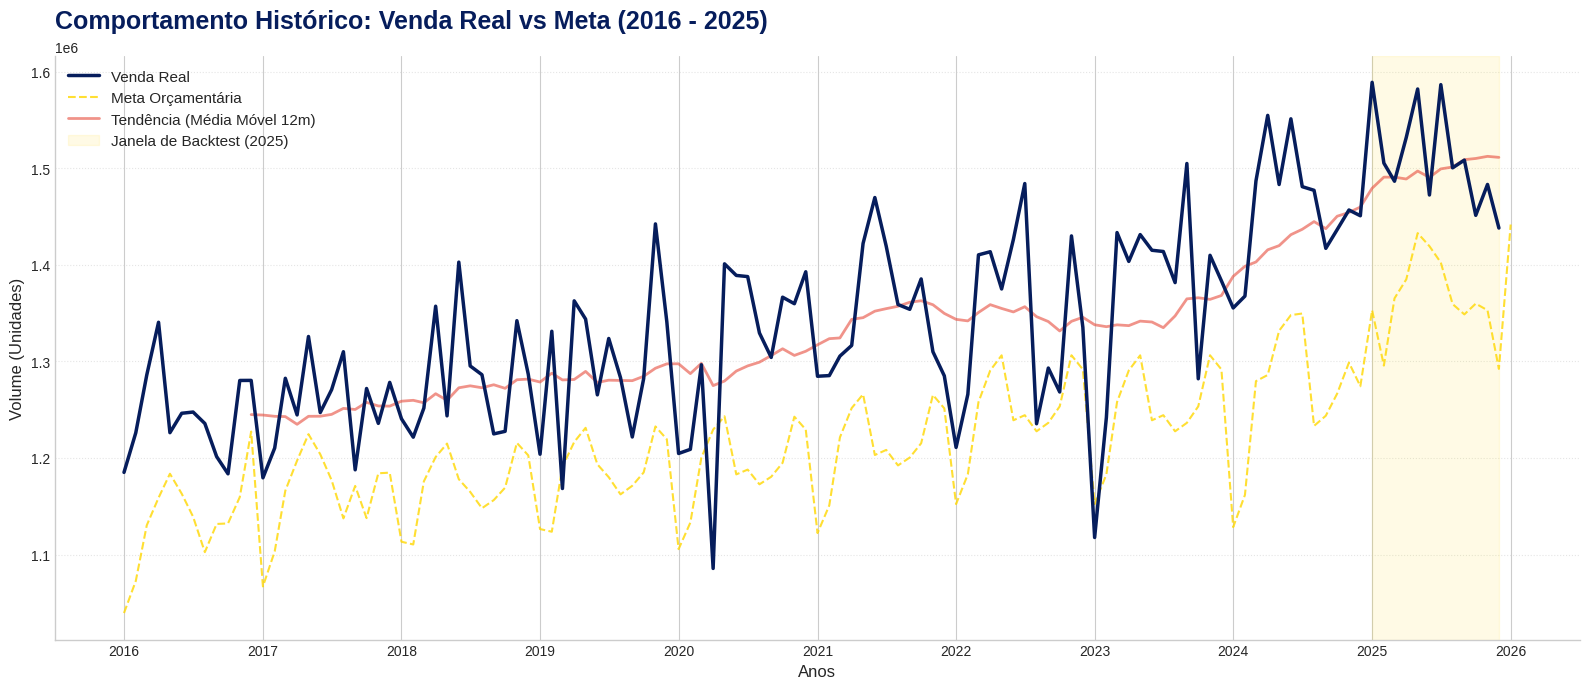

Gráfico exploratório gerado! Destaque visual para o período de backtest (2025).


In [52]:
# CONFIGURAÇÃO VISUAL E PLOTAGEM DO DASHBOARD HISTÓRICO

plt.figure(figsize=(16, 7), facecolor='white')

AZUL_CORP = '#061d5c'
DOURADO = '#FFD700'
VERMELHO_TEND = '#e74c3c'

# --- 1. Camada de Venda Real ---
plt.plot(df_plot.index, df_plot['Venda_Real'], color=AZUL_CORP, linewidth=2.5,
         label='Venda Real', zorder=3)

# --- 2. Camada de Orçamento (Meta) ---
plt.plot(df_plot.index, df_plot['Meta_Orcamento'], color=DOURADO, linewidth=1.5,
         linestyle='--', label='Meta Orçamentária', alpha=0.8)

# --- 3. Camada de Tendência (Média Móvel 12 meses) ---
media_movel = df_plot['Venda_Real'].rolling(window=12).mean()
plt.plot(df_plot.index, media_movel, color=VERMELHO_TEND, linewidth=2,
         label='Tendência (Média Móvel 12m)', alpha=0.6)

# --- 4. Destaque do Período de Backtest (2025) ---
# Sombreado amarelo para indicar que 2025 será o ano de validação dos modelos
plt.axvspan('2025-01-01', '2025-12-01', color=DOURADO, alpha=0.1, label='Janela de Backtest (2025)')

# --- Formatação Estética do Gráfico ---
plt.title("Comportamento Histórico: Venda Real vs Meta (2016 - 2025)",
          fontsize=18, fontweight='bold', color=AZUL_CORP, pad=20, loc='left')
plt.xlabel("Anos", fontsize=12)
plt.ylabel("Volume (Unidades)", fontsize=12)

# Formatação do Eixo X para mostrar anos de forma clara
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

print("Gráfico exploratório gerado! Destaque visual para o período de backtest (2025).")

### Análise de Causa-Efeito: Vendas vs. Pressão de Estoque:
Nesta análise, cruzamos o desempenho comercial com a saúde logística. Diferente da série histórica simples, aqui focamos no período de 2022 em diante, onde possuímos dados granulares de inventário.

A hipótese central é que o volume de vendas possui uma correlação negativa com os níveis de estoque excedentes na rede:

*   Pressão Positiva (> 0): Indica estoque acima da política ideal (excesso). Tende a reduzir novas vendas nos meses subsequentes.
*  Pressão Negativa (< 0): Indica estoque abaixo do ideal (risco de ruptura). Pode sinalizar uma demanda reprimida ou necessidade urgente de reposição.

Para esta visualização, utilizamos um Gráfico de Eixos Duplos (TwinX), permitindo a comparação de métricas com diferentes unidades de grandeza.

In [53]:
# PREPARAÇÃO DOS DADOS DE SAÚDE LOGÍSTICA

# Filtro para período com dados de estoque disponíveis (2022 em diante)
df_est = df_hist.loc[df_hist.index >= '2022-01-01']

print(f"Analisando correlação de estoque para {len(df_est)} períodos.")

Analisando correlação de estoque para 60 períodos.


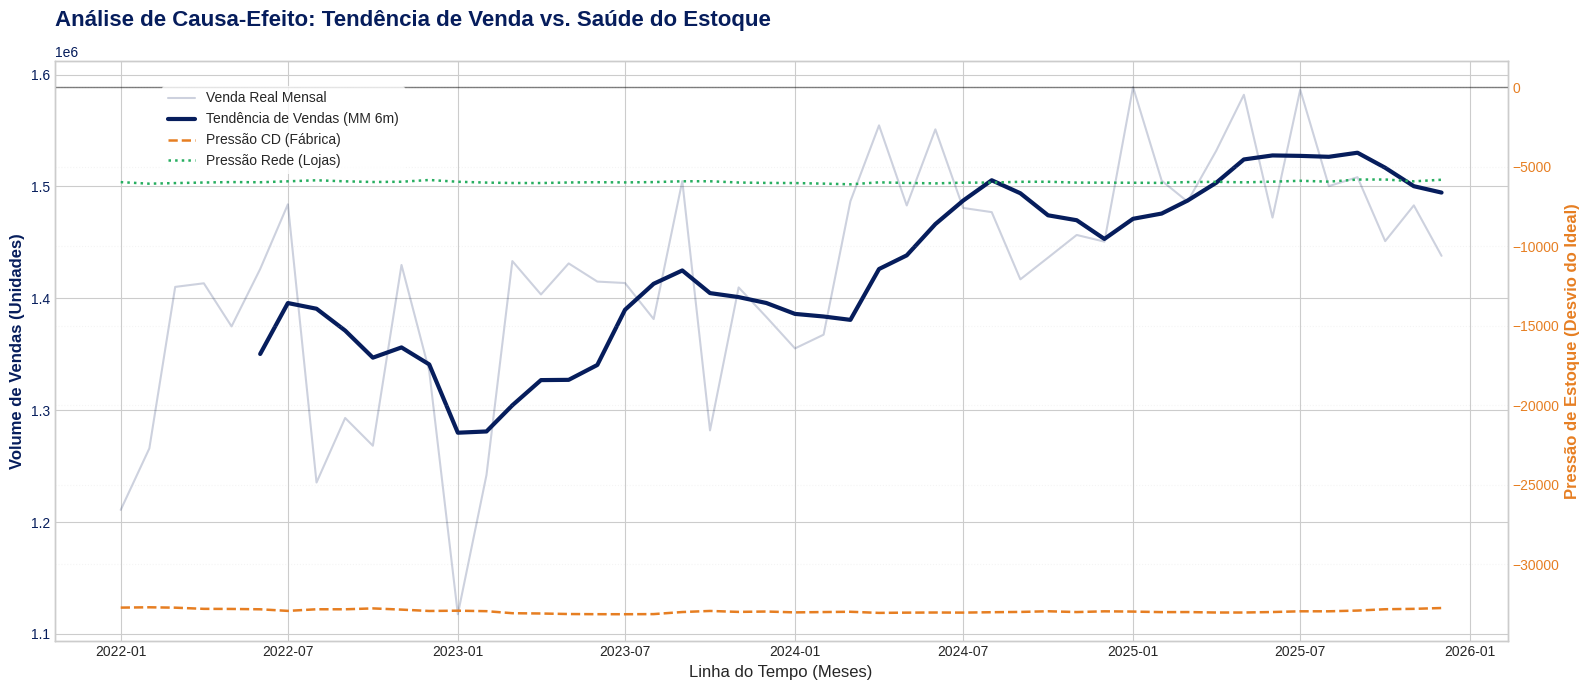

Gráfico de correlação gerado. Dica: Verifique se quedas na tendência azul seguem picos nas linhas laranja/verde.


In [54]:
# PLOTAGEM DO GRÁFICO DE CAUSA-EFEITO (VENDAS VS PRESSÃO)
fig, ax1 = plt.subplots(figsize=(16, 7), facecolor='white')

# --- Eixo Primário (Esquerda): Volume de Vendas ---
ax1.set_xlabel('Linha do Tempo (Meses)', fontsize=12)
ax1.set_ylabel('Volume de Vendas (Unidades)', color='#061d5c', fontweight='bold', fontsize=12)

# Venda mensal (suavizada com alpha) e Tendência de 6 meses
ax1.plot(df_est.index, df_est['Venda_Real'], color='#061d5c', alpha=0.2, label='Venda Real Mensal')
ax1.plot(df_est.index, df_est['Venda_Real'].rolling(6).mean(), color='#061d5c',
         linewidth=3, label='Tendência de Vendas (MM 6m)')
ax1.tick_params(axis='y', labelcolor='#061d5c')

# --- Eixo Secundário (Direita): Pressão de Estoque ---
ax2 = ax1.twinx()
ax2.set_ylabel('Pressão de Estoque (Desvio do Ideal)', color='#e67e22', fontweight='bold', fontsize=12)

# Pressão de CD e Rede
ax2.plot(df_est.index, df_est['Pressao_CD'], color='#e67e22', linestyle='--',
         linewidth=1.8, label='Pressão CD (Fábrica)')
ax2.plot(df_est.index, df_est['Pressao_Rede'], color='#27ae60', linestyle=':',
         linewidth=1.8, label='Pressão Rede (Lojas)')

# Linha de Equilíbrio (Estoque Ideal = 0)
ax2.axhline(0, color='black', linewidth=1, alpha=0.5, linestyle='-')

ax2.tick_params(axis='y', labelcolor='#e67e22')

# Finalização e Legenda
plt.title('Análise de Causa-Efeito: Tendência de Venda vs. Saúde do Estoque',
          fontsize=16, fontweight='bold', pad=25, color='#061d5c', loc='left')

fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88), frameon=True, facecolor='white', edgecolor='none')
plt.grid(alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

print("Gráfico de correlação gerado. Dica: Verifique se quedas na tendência azul seguem picos nas linhas laranja/verde.")

#2. Modelagem Preditiva e Validação Estatística

Nesta fase, iniciamos a construção dos modelos de inteligência de dados. O sucesso de uma previsão de demanda não depende apenas do algoritmo, mas da metodologia de validação. Adotamos a estratégia de Backtesting, simulando como o modelo teria se comportado no passado recente.

## 2.1 Separação dos Dados (Treino vs. Teste):

Para garantir a imparcialidade da análise, dividimos a série temporal em três blocos distintos:


*   **Conjunto de Treino (2016 - 2024)**: 108 meses de histórico para aprendizado de tendência e sazonalidade.
*   **Conjunto de Teste (2025)**: 12 meses isolados que funcionam como o "Gabarito". O modelo não tem acesso a esses dados durante o ajuste dos parâmetros.
* **Horizonte de Aplicação (2026)**: Período de execução real do projeto.

In [55]:
# CARGA E PREPARAÇÃO PARA MODELAGEM

# Verificação de existência do arquivo consolidado
if not os.path.exists(ARQUIVO_MASTER):
    raise FileNotFoundError("Arquivo mestre não encontrado. Execute a etapa de ETL primeiro.")

# Leitura garantindo o índice temporal
df_master = pd.read_excel(ARQUIVO_MASTER, index_col=0, parse_dates=True)

print(f"Base Master carregada. Total de períodos: {len(df_master)} meses.")

Base Master carregada. Total de períodos: 132 meses.


In [56]:
# DIVISÃO DA SÉRIE (TREINO: ATÉ 2024 | TESTE: 2025)
print("Aplicando máscara temporal para validação Out-of-Sample...")

# 1. Isolamos o ano de 2026 para que ele não interfira na validação de acurácia
df_validacao_historica = df_master.loc[df_master.index < '2026-01-01']

# 2. Definição do ponto de corte para o teste (Gabarito de 2025)
data_corte = pd.to_datetime('2025-01-01')

# TREINO: Histórico profundo para aprendizado
df_treino = df_validacao_historica.loc[df_validacao_historica.index < data_corte]

# TESTE: O ano de 2025 completo (12 meses)
df_teste = df_validacao_historica.loc[df_validacao_historica.index >= data_corte]

# RESUMO DA ESTRUTURA
print("ESTRUTURA DE DADOS PARA MODELAGEM")
print("="*50)

def imprimir_info(nome, df, cor):
    print(f"{cor} {nome} ({len(df)} meses):")
    print(f"   - {df.index.min().strftime('%b/%Y')} até {df.index.max().strftime('%b/%Y')}")

imprimir_info(" CONJUNTO DE TREINO", df_treino, "")
imprimir_info(" CONJUNTO DE TESTE ", df_teste, "")

print("="*50)

# Verificação Crítica: O teste precisa ter 12 meses para representar a sazonalidade completa
if len(df_teste) == 12:
    print("Sucesso: O conjunto de teste cobre exatamente o ciclo anual de 2025.")
else:
    print(f"Alerta: Conjunto de teste com {len(df_teste)} meses. Verifique o arquivo original.")

Aplicando máscara temporal para validação Out-of-Sample...
ESTRUTURA DE DADOS PARA MODELAGEM
  CONJUNTO DE TREINO (108 meses):
   - Jan/2016 até Dec/2024
  CONJUNTO DE TESTE  (12 meses):
   - Jan/2025 até Dec/2025
Sucesso: O conjunto de teste cobre exatamente o ciclo anual de 2025.


# 3. Modelos

Nesta etapa central do projeto, implementamos um ciclo de experimentação e validação com sete abordagens distintas. O objetivo é encontrar o modelo que melhor equilibra a precisão estatística com a realidade operacional.

A estratégia consiste em partir de modelos de suavização simples (Base) até modelos de aprendizado estocástico com variáveis externas.

Os 7 Modelos em Avaliação:

1. **SES:** Suavização Exponencial Simples.

2. **Holt:** Suavização com Tendência Linear.

3. **Holt-Winters:** Suavização com Tendência e Sazonalidade.

4. **Decomposição Clássica**

5. **STL:** Decomposição de Séries Temporais via Loess.

6. **ARIMA:** Modelo Autorregressivo Integrado de Médias Móveis.

7. **SARIMAX:** ARIMA Sazonal com Variáveis Exógenas (Estoque e Metas).

## Modelo 1: Suavização Exponencial Simples (SES)

O SES (Simple Exponential Smoothing) é o nosso Modelo Baseline. Ele define o patamar mínimo de aceitação: se um modelo avançado não superar o SES, sua complexidade não se justifica.

### A Lógica de Aplicação

O SES prevê o futuro baseando-se em uma média ponderada onde os dados mais recentes possuem maior peso. O peso é controlado pelo parâmetro $\alpha$ (alfa), estimado automaticamente pelo algoritmo via Máxima Verossimilhança durante o fit().

A equação fundamental é:

$$\hat{y}_{t+1} = \alpha y_t + (1 - \alpha) \hat{y}_t$$

Onde:

*   $\hat{y}_{t+1}$ = é o valor da previsão para o próximo mês (ex: Janeiro/2026);
*   $\alpha$ (alfa) = é o fator de suavização (um valor entre 0 e 1). Ele determina o "peso" dado à observação mais recente;
*   $y_t$ = é o valor real observado no mês atual (o que de fato vendeu);
*   $\hat{y}_t$ = é o valor que o modelo tinha previsto anteriormente para o mês atual;
*   $(1 - \alpha)$ = é o peso dado ao histórico acumulado, garantindo que o modelo não ignore totalmente o passado.



### Métricas de Avaliação:

Para medir o desempenho, utilizamos duas dimensões de erro:

**MAPE (Mean Absolute Percentage Error):** Mede a precisão do faturamento mensal.

$$MAPE = \frac{100\%}{n} \sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|$$

Onde:

*   $n$ = é o número total de meses analisados no conjunto de teste (que, nesse caso, $n=12$ para o ano de 2025);
*   $\sum_{t=1}^{n}$ = é o símbolo de somatório, indicando que vamos somar os erros de todos os meses de Janeiro a Dezembro;
*   $y_t$ = é o volume real de vendas do mês $t$;
*   $\hat{y}_t$ = é o volume previsto pelo modelo para o mês $t$;
*   $\left| \dots \right|$ = representa o valor absoluto (módulo). Ele garante que erros negativos e positivos não se anulem, focando na distância real do erro;
*    $\frac{y_t - \hat{y}_t}{y_t}$ = é o cálculo do erro relativo (a diferença dividida pelo real), que transforma a unidade de "alguma coisa" em "percentual";
*   onde $100\%$ = é o fator multiplicador para converter o resultado final em uma escala de 0 a 100%.

**Acurácia Volumétrica:** Mede a precisão do volume total anual.

In [57]:
# TREINAMENTO E PREVISÃO (SES)

print("Iniciando Modelo Baseline (SES)...")

# O modelo fit() estima automaticamente o melhor 'alfa' para os dado
modelo_ses = SimpleExpSmoothing(df_treino['Venda_Real'], initialization_method="estimated").fit()

# Gerando a previsão para os 12 meses do conjunto de teste (2025)
previsao_ses = modelo_ses.forecast(len(df_teste))

print(f"Treinamento concluído. Alfa otimizado: {modelo_ses.model.params['smoothing_level']:.4f}")

Iniciando Modelo Baseline (SES)...
Treinamento concluído. Alfa otimizado: 0.1530


In [58]:
# CÁLCULO DE MÉTRICAS DE PERFORMANCE
# Consolidação dos resultados para comparação
df_res_ses = pd.DataFrame({
    'Realizado': df_teste['Venda_Real'],
    'Previsao': previsao_ses
}).astype(float)

# 1. MAPE (Mean Absolute Percentage Error)
# Representa o erro médio percentual em cada mês
df_res_ses['Erro_Abs_Pct'] = np.abs((df_res_ses['Realizado'] - df_res_ses['Previsao']) / df_res_ses['Realizado'])
mape_ses = df_res_ses['Erro_Abs_Pct'].mean() * 100

# 2. Acurácia Volumétrica (Assertividade do Volume Anual)
vol_real = df_res_ses['Realizado'].sum()
vol_prev = df_res_ses['Previsao'].sum()
acc_vol_ses = 100 - (abs(vol_prev - vol_real) / vol_real * 100)

print(f"MAPE SES: {mape_ses:.1f}%")
print(f"Acurácia Volumétrica: {acc_vol_ses:.1f}%")

MAPE SES: 4.1%
Acurácia Volumétrica: 95.9%


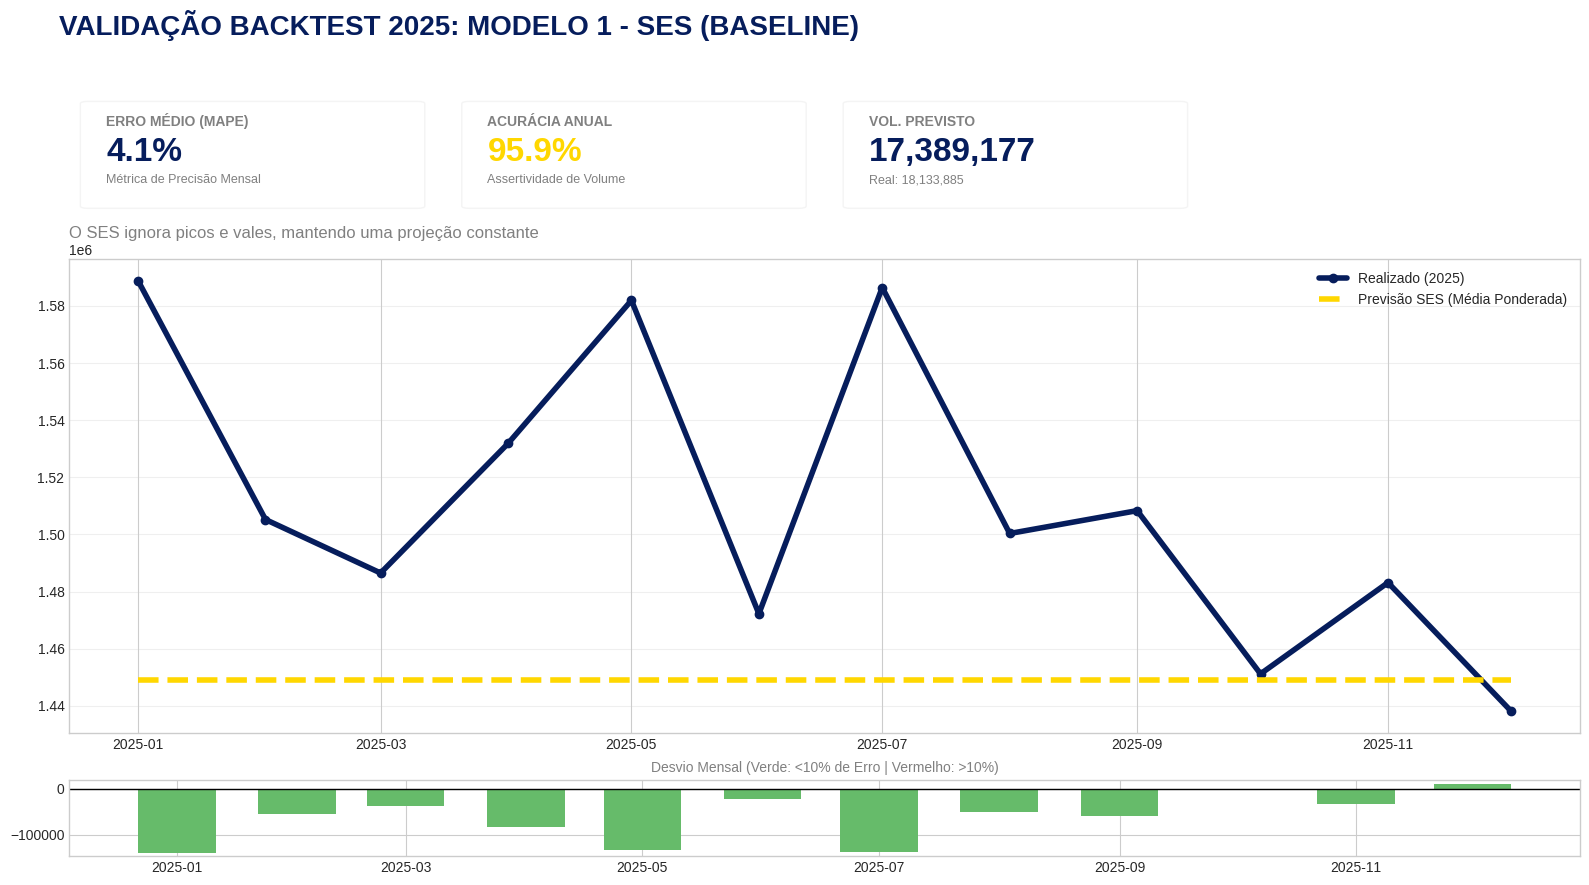

In [59]:
# DASHBOARD DE VALIDAÇÃO (SES)

# Configuração do Layout (Grid 3x4)
fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, "VALIDAÇÃO BACKTEST 2025: MODELO 1 - SES (BASELINE)",
         fontsize=20, fontweight='bold', color='#061d5c')

# Função para criar os Cards de KPI
def criar_card(pos, titulo, valor, sub, cor='#061d5c'):
    ax = fig.add_subplot(pos); ax.axis('off')
    rect = patches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9, boxstyle="round,pad=0.02",
                                  ec='#f4f4f4', fc='white', transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(0.1, 0.75, titulo, transform=ax.transAxes, fontsize=10, color='gray', fontweight='bold')
    ax.text(0.1, 0.45, valor, transform=ax.transAxes, fontsize=24, fontweight='bold', color=cor)
    ax.text(0.1, 0.25, sub, transform=ax.transAxes, fontsize=9, color='gray')

criar_card(gs[0, 0], "ERRO MÉDIO (MAPE)", f"{mape_ses:.1f}%", "Métrica de Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA ANUAL", f"{acc_vol_ses:.1f}%", "Assertividade de Volume", '#FFD700')
criar_card(gs[0, 2], "VOL. PREVISTO", f"{vol_prev:,.0f}", f"Real: {vol_real:,.0f}")

# --- Gráfico Principal de Aderência ---
ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_ses.index, df_res_ses['Realizado'], color='#061d5c', linewidth=4,
             marker='o', label='Realizado (2025)', zorder=5)
ax_main.plot(df_res_ses.index, df_res_ses['Previsao'], color='#FFD700', linewidth=4,
             linestyle='--', label='Previsão SES (Média Ponderada)', zorder=6)

ax_main.set_title("O SES ignora picos e vales, mantendo uma projeção constante",
                  fontsize=12, color='gray', loc='left', pad=15)
ax_main.legend(frameon=False)
ax_main.grid(axis='y', alpha=0.3)

# --- Gráfico de Resíduos (Erro Mensal) ---
ax_res = fig.add_subplot(gs[2, :])
erros_mensais = df_res_ses['Previsao'] - df_res_ses['Realizado']
cores_erro = ['#66bb6a' if abs(e)/r < 0.1 else '#ef5350' for e, r in zip(erros_mensais, df_res_ses['Realizado'])]

ax_res.bar(df_res_ses.index, erros_mensais, color=cores_erro, width=20)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_title("Desvio Mensal (Verde: <10% de Erro | Vermelho: >10%)", fontsize=10, color='gray')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

## Modelo 2: Suavização Exponencial Dupla (Modelo de Holt)
O Modelo de Holt é uma evolução direta do SES, introduzindo uma segunda equação para capturar a Tendência ($T$) da série temporal. Enquanto o SES assume que o futuro é uma média plana, o Holt consegue identificar se está em um ciclo de crescimento ou retração constante, projetando essa inclinação para o horizonte de previsão.


### A Lógica de Aplicação

Diferente do modelo anterior, o Holt utiliza dois parâmetros de ajuste:
1.   $\alpha$ (Alfa): Para suavizar o nível da série.
2.   $\beta$ (Beta): Para suavizar a inclinação (tendência).

### As equações fundamentais são:

1.   Nível: $L_t = \alpha y_t + (1 - \alpha)(L_{t-1} + T_{t-1})$
2.   Tendência: $T_t = \beta(L_t - L_{t-1}) + (1 - \beta)T_{t-1}$
3.   Previsão: $\hat{y}_{t+h} = L_t + hT_t$

### Onde:


*   $L_t$ = é o Nível estimado da série no tempo $t$ (o valor base atualizado);
*   $T_t$ = é a Tendência estimada (a "velocidade" de crescimento ou queda);
*   $\alpha$ (alfa) = é o fator de suavização do nível (0 a 1);
*   $\beta$ (beta) = é o fator de suavização da tendência (0 a 1);
*   $h$ = é o horizonte de previsão (quantos meses à frente estamos prevendo);
*   $y_t$ = é o valor real observado no mês $t$.




In [60]:
# TREINAMENTO E PREDIÇÃO (HOLT)

print("Iniciando Modelo de Holt (Tendência)...")

# O modelo Holt(treino) ativa automaticamente a componente de tendência linear
modelo_holt = Holt(df_treino['Venda_Real'], initialization_method="estimated").fit()

# Gerando a previsão para os 12 meses de 2025
previsao_holt = modelo_holt.forecast(len(df_teste))

print(f"Treinamento concluído.")
print(f"Parâmetros: Alfa (Nível)={modelo_holt.model.params['smoothing_level']:.4f} | Beta (Trend)={modelo_holt.model.params['smoothing_trend']:.4f}")

Iniciando Modelo de Holt (Tendência)...
Treinamento concluído.
Parâmetros: Alfa (Nível)=0.0655 | Beta (Trend)=0.0000


In [61]:
# CONSOLIDAÇÃO DE RESULTADOS E MÉTRICAS

# Tabela de resultados para comparação
df_res_holt = pd.DataFrame({
    'Realizado': df_teste['Venda_Real'],
    'Previsao': previsao_holt
}).astype(float)

# Métricas de Performance
df_res_holt['Erro_Abs_Pct'] = np.abs((df_res_holt['Realizado'] - df_res_holt['Previsao']) / df_res_holt['Realizado'])
mape_holt = df_res_holt['Erro_Abs_Pct'].mean() * 100

vol_real = df_res_holt['Realizado'].sum()
vol_prev = df_res_holt['Previsao'].sum()
acc_vol_holt = 100 - (abs(vol_prev - vol_real) / vol_real * 100)

print(f"MAPE Holt: {mape_holt:.1f}%")
print(f"Acurácia Volumétrica: {acc_vol_holt:.1f}%")

MAPE Holt: 4.1%
Acurácia Volumétrica: 96.3%


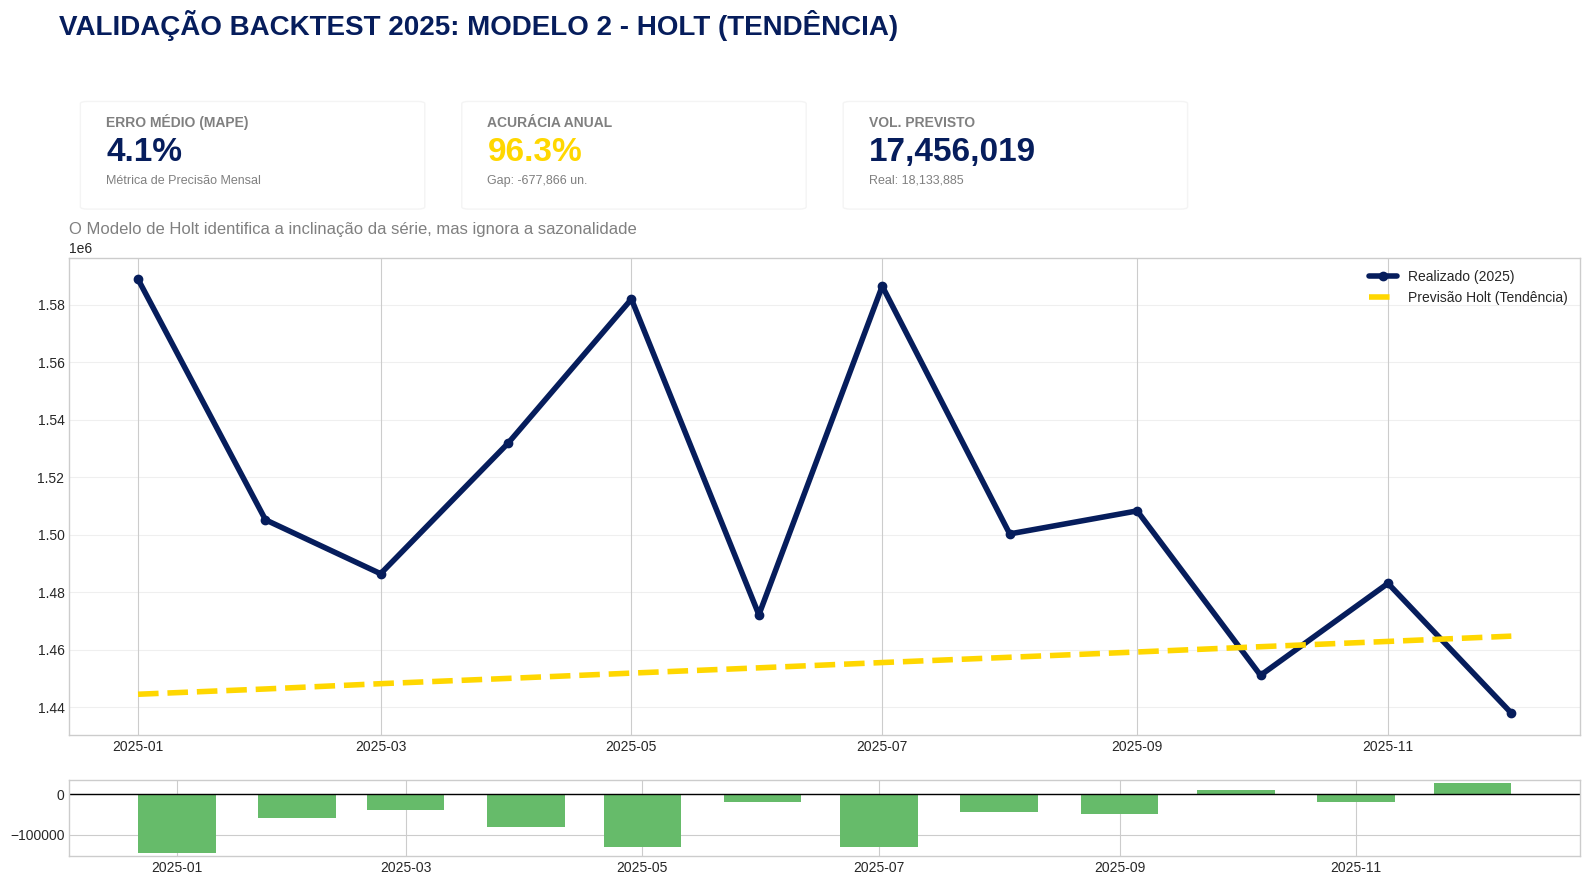

In [62]:
# DASHBOARD EXECUTIVO DE VALIDAÇÃO (HOLT)

fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, "VALIDAÇÃO BACKTEST 2025: MODELO 2 - HOLT (TENDÊNCIA)", fontsize=20, fontweight='bold', color='#061d5c')

# Cards de KPI
gap_holt = vol_prev - vol_real
criar_card(gs[0, 0], "ERRO MÉDIO (MAPE)", f"{mape_holt:.1f}%", "Métrica de Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA ANUAL", f"{acc_vol_holt:.1f}%", f"Gap: {gap_holt:+,.0f} un.", '#FFD700')
criar_card(gs[0, 2], "VOL. PREVISTO", f"{vol_prev:,.0f}", f"Real: {vol_real:,.0f}")

# Gráfico Principal
ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_holt.index, df_res_holt['Realizado'], color='#061d5c', linewidth=4, marker='o', label='Realizado (2025)')
ax_main.plot(df_res_holt.index, df_res_holt['Previsao'], color='#FFD700', linewidth=4, linestyle='--', label='Previsão Holt (Tendência)')
ax_main.set_title("O Modelo de Holt identifica a inclinação da série, mas ignora a sazonalidade", fontsize=12, color='gray', loc='left')
ax_main.legend(frameon=False); ax_main.grid(axis='y', alpha=0.3)

# Gráfico de Resíduos
ax_res = fig.add_subplot(gs[2, :])
erros_holt = df_res_holt['Previsao'] - df_res_holt['Realizado']
cores_holt = ['#66bb6a' if abs(e)/r < 0.1 else '#ef5350' for e, r in zip(erros_holt, df_res_holt['Realizado'])]
ax_res.bar(df_res_holt.index, erros_holt, color=cores_holt, width=20)
ax_res.axhline(0, color='black', linewidth=1)

plt.tight_layout(); plt.subplots_adjust(top=0.88); plt.show()

## Modelo 3: Suavização Exponencial Tripla (Holt-Winters)
O modelo de Holt-Winters representa o estado da arte na família de suavização exponencial. Ele introduz uma terceira equação matemática para capturar a Sazonalidade ($S$), permitindo que o algoritmo aprenda os ciclos repetitivos de 12 meses. Diferente dos modelos anteriores, o Holt-Winters compreende que determinados meses (como o Pico de Maio) possuem um comportamento sistematicamente superior à média.

### A Lógica de Aplicação

O modelo utiliza três equações simultâneas para estimar o Nível ($L$), a Tendência ($T$) e a Sazonalidade ($S$). Optamos pela abordagem Aditiva para tendência e sazonalidade, visando maior estabilidade nas projeções de volume.

### As equações fundamentais são:

1.   **Nível:** $L_t = \alpha (y_t - S_{t-m}) + (1 - \alpha)(L_{t-1} + T_{t-1})$
2.   **Tendência:** $T_t = \beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1}$
3.   **Sazonalidade:** $S_t = \gamma (y_t - L_{t-1} - T_{t-1}) + (1 - \gamma) S_{t-m}$
4.   **Previsão:** $\hat{y}_{t+h} = L_t + hT_t + S_{t+h-m}$

### Onde:

*   $L_t$ = é o Nível estimado (o valor base da série);
*   $T_t$ = é a Tendência estimada (o crescimento linear);
*   $S_t$ = é o Fator Sazonal (o ajuste específico para cada mês do ano);
*   $m$ = é o período sazonal (no nosso caso, $m=12$ meses);
*   $\alpha, \beta, \gamma$ = são os fatores de suavização para nível, tendência e sazonalidade, respectivamente;
*    $\hat{y}_{t+h}$ = é o valor final da previsão para o horizonte $h$.




In [63]:
# TREINAMENTO E PREDIÇÃO (HOLT-WINTERS)

print("Iniciando Modelo de Holt-Winters (Sazonalidade)...")

# Treinamento: m=12 define o ciclo anual
modelo_hw = ExponentialSmoothing(df_treino['Venda_Real'],
                                 trend='add',
                                 seasonal='add',
                                 seasonal_periods=12,
                                 initialization_method="estimated").fit()

previsao_hw = modelo_hw.forecast(len(df_teste))

print(f"Treinamento concluído. Gama (Sazonalidade): {modelo_hw.model.params['smoothing_seasonal']:.4f}")

Iniciando Modelo de Holt-Winters (Sazonalidade)...
Treinamento concluído. Gama (Sazonalidade): 0.0816


In [64]:
# CONSOLIDAÇÃO DE RESULTADOS E MÉTRICAS
df_res_hw = pd.DataFrame({
    'Realizado': df_teste['Venda_Real'],
    'Previsao': previsao_hw
}).astype(float)

# Métricas de Performance
df_res_hw['Erro_Abs_Pct'] = np.abs((df_res_hw['Realizado'] - df_res_hw['Previsao']) / df_res_hw['Realizado'])
mape_hw = df_res_hw['Erro_Abs_Pct'].mean() * 100

vol_real = df_res_hw['Realizado'].sum()
vol_prev = df_res_hw['Previsao'].sum()
acc_vol_hw = 100 - (abs(vol_prev - vol_real) / vol_real * 100)

print(f" MAPE Holt-Winters: {mape_hw:.1f}% | Acurácia Vol.: {acc_vol_hw:.1f}%")

 MAPE Holt-Winters: 5.6% | Acurácia Vol.: 94.6%


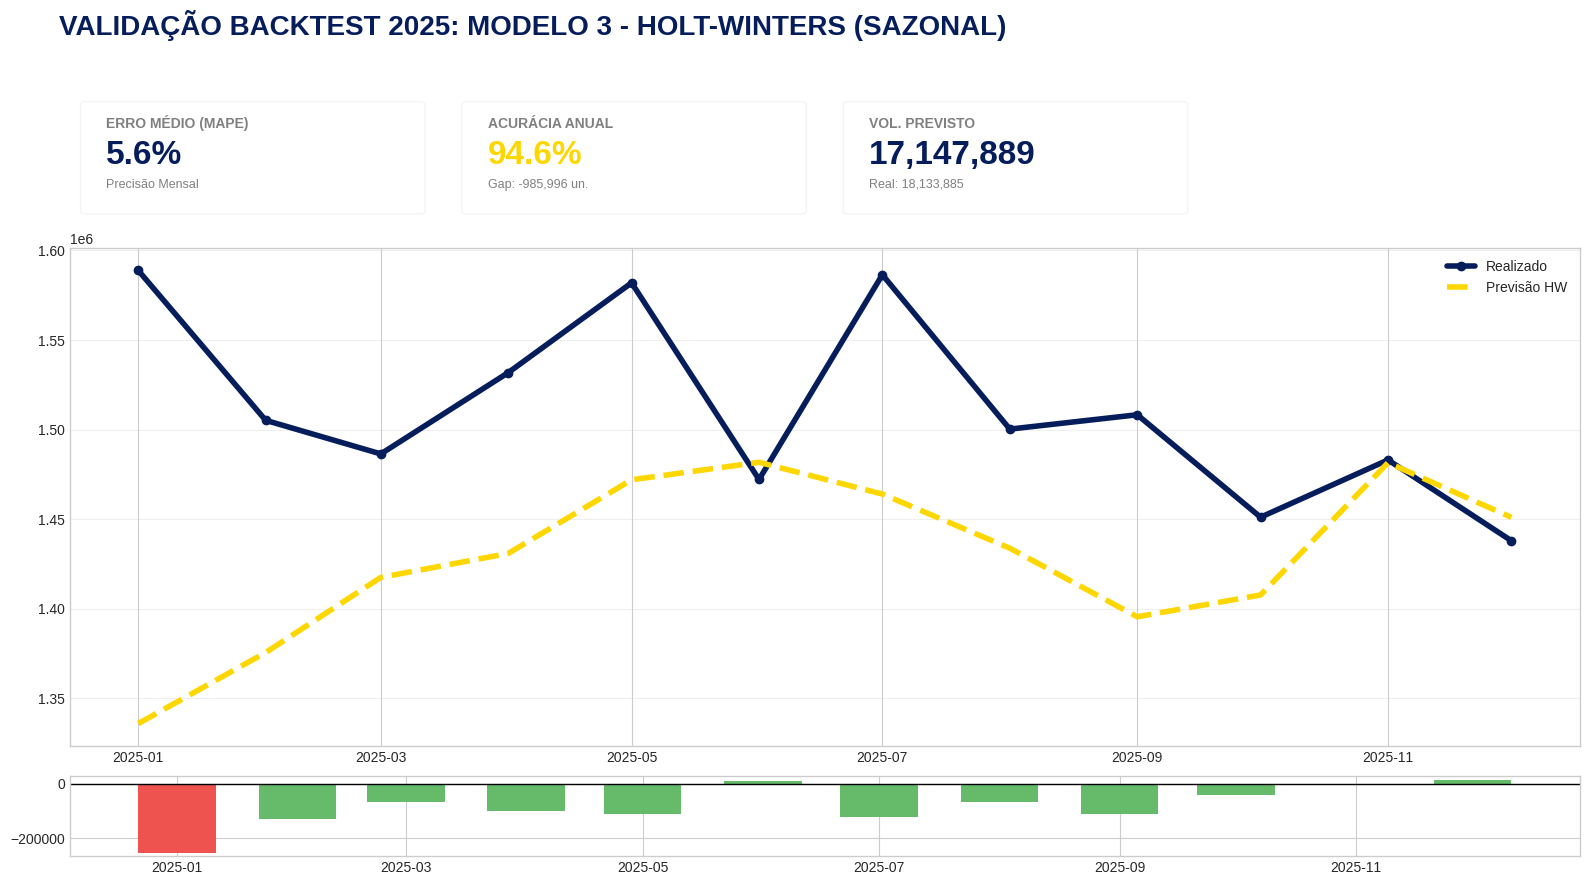

In [65]:
# DASHBOARD EXECUTIVO E DIAGNÓSTICO

# 1. Dashboard Principal
fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, "VALIDAÇÃO BACKTEST 2025: MODELO 3 - HOLT-WINTERS (SAZONAL)", fontsize=20, fontweight='bold', color='#061d5c')

gap_hw = vol_prev - vol_real
criar_card(gs[0, 0], "ERRO MÉDIO (MAPE)", f"{mape_hw:.1f}%", "Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA ANUAL", f"{acc_vol_hw:.1f}%", f"Gap: {gap_hw:+,.0f} un.", '#FFD700')
criar_card(gs[0, 2], "VOL. PREVISTO", f"{vol_prev:,.0f}", f"Real: {vol_real:,.0f}")

ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_hw.index, df_res_hw['Realizado'], color='#061d5c', linewidth=4, marker='o', label='Realizado')
ax_main.plot(df_res_hw.index, df_res_hw['Previsao'], color='#FFD700', linewidth=4, linestyle='--', label='Previsão HW')
ax_main.legend(frameon=False); ax_main.grid(axis='y', alpha=0.3)

ax_res = fig.add_subplot(gs[2, :])
diffs = df_res_hw['Previsao'] - df_res_hw['Realizado']
cores = ['#66bb6a' if abs(e)/r < 0.1 else '#ef5350' for e, r in zip(diffs, df_res_hw['Realizado'])]
ax_res.bar(df_res_hw.index, diffs, color=cores, width=20)
ax_res.axhline(0, color='black', linewidth=1)

plt.tight_layout(); plt.subplots_adjust(top=0.88); plt.show()


## Modelo 4. Decomposição Clássica

A Decomposição Clássica baseia-se na premissa de que uma série temporal pode ser desmembrada em componentes ortogonais.

### A Lógica de Aplicação

O modelo assume uma estrutura Aditiva, onde a venda observada é a soma de seus componentes. Como a decomposição por si só não gera previsões futuras (ela apenas analisa o passado), utilizamos uma abordagem híbrida: extraímos a sazonalidade média histórica e projetamos a tendência utilizando Suavização Exponencial.

### A equação fundamental é:

$$y_t = T_t + S_t + R_t$$

#### Onde:

*   $y_t$ = é o valor real observado (Venda Real);
*   $T_t$ = é o componente de Tendência, calculado via Médias Móveis para suavizar flutuações;
*   $S_t$ = é o componente de Sazonalidade, que representa os desvios repetitivos em ciclos de 12 meses;
*   $R_t$ = é o Resíduo ou Erro, representando a aleatoriedade que os componentes anteriores não capturaram.


In [66]:
# TREINAMENTO E DECOMPOSIÇÃO

print("Iniciando Decomposição Clássica (Treino 2016-2024)...")

# 1. Decomposição dos dados de treino
# period=12 define o ciclo anual
decomposicao = seasonal_decompose(df_treino['Venda_Real'], model='additive', period=12)

# 2. Extração da Sazonalidade Estática
# Pegamos o padrão dos últimos 12 meses do treino para replicar em 2025
sazonalidade_estatica = decomposicao.seasonal[-12:].values

# 3. Projeção da Tendência (Usando SES sobre a tendência extraída)
# Removemos os NaNs gerados pela média móvel da decomposição
modelo_tendencia = SimpleExpSmoothing(decomposicao.trend.dropna(), initialization_method="estimated").fit()
tendencia_projetada = modelo_tendencia.forecast(12).values

# 4. Composição da Previsão: Tendência Projetada + Sazonalidade Estática
previsao_classica = tendencia_projetada + sazonalidade_estatica

print(f"Decomposição concluída. Tendência projetada via SES (alfa={modelo_tendencia.model.params['smoothing_level']:.4f})")

Iniciando Decomposição Clássica (Treino 2016-2024)...
Decomposição concluída. Tendência projetada via SES (alfa=1.0000)


In [67]:
# CONSOLIDAÇÃO DE RESULTADOS E MÉTRICAS
df_res_classica = pd.DataFrame({
    'Realizado': df_teste['Venda_Real'],
    'Previsao': previsao_classica
}).astype(float)

# Cálculos de Erro
df_res_classica['Erro_Abs_Pct'] = np.abs((df_res_classica['Realizado'] - df_res_classica['Previsao']) / df_res_classica['Realizado'])
mape_classica = df_res_classica['Erro_Abs_Pct'].mean() * 100

vol_real = df_res_classica['Realizado'].sum()
vol_prev = df_res_classica['Previsao'].sum()
acc_vol_classica = 100 - (abs(vol_prev - vol_real) / vol_real * 100)

print(f"MAPE Clássica: {mape_classica:.1f}% | Acurácia Vol.: {acc_vol_classica:.1f}%")

MAPE Clássica: 4.4% | Acurácia Vol.: 96.4%


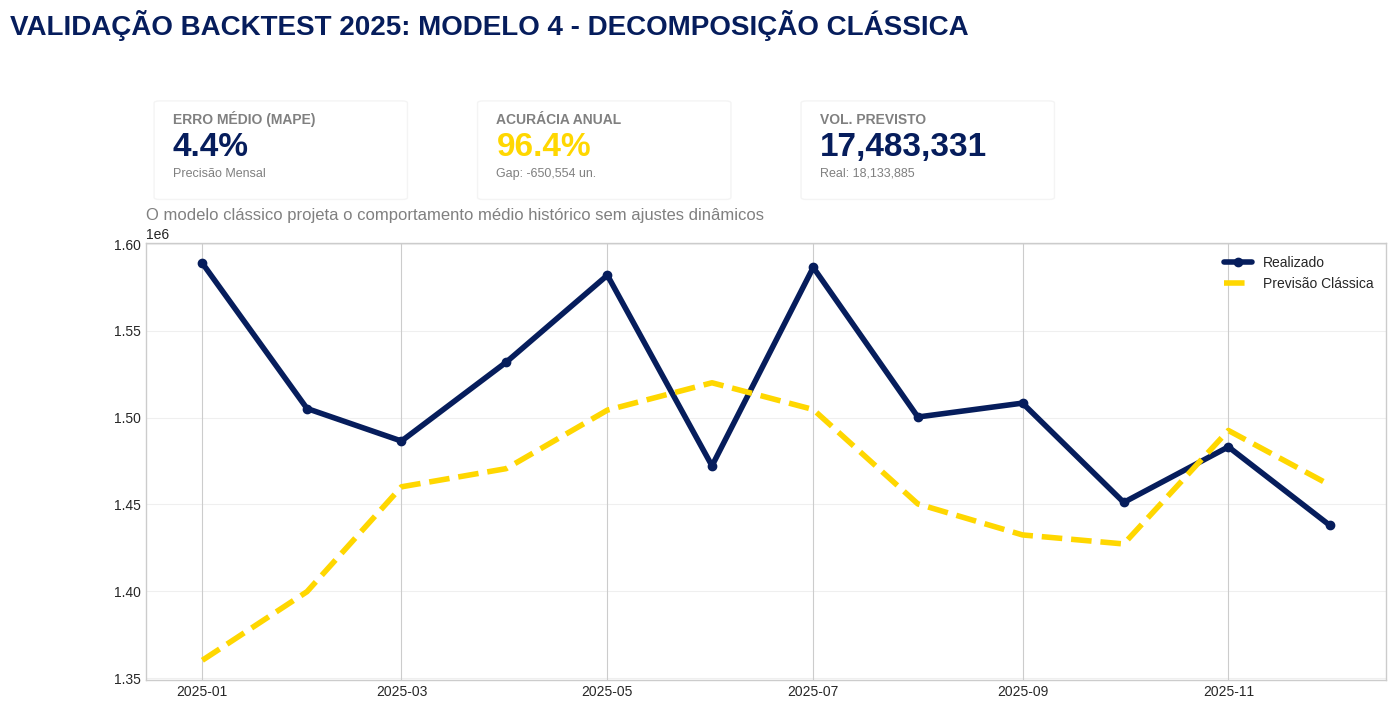

In [68]:
# DASHBOARD EXECUTIVO E DIAGNÓSTICO (PADRONIZADO)
# 1. Dashboard Principal
fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, "VALIDAÇÃO BACKTEST 2025: MODELO 4 - DECOMPOSIÇÃO CLÁSSICA", fontsize=20, fontweight='bold', color='#061d5c')

gap_classica = vol_prev - vol_real
criar_card(gs[0, 0], "ERRO MÉDIO (MAPE)", f"{mape_classica:.1f}%", "Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA ANUAL", f"{acc_vol_classica:.1f}%", f"Gap: {gap_classica:+,.0f} un.", '#FFD700')
criar_card(gs[0, 2], "VOL. PREVISTO", f"{vol_prev:,.0f}", f"Real: {vol_real:,.0f}")

ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_classica.index, df_res_classica['Realizado'], color='#061d5c', linewidth=4, marker='o', label='Realizado')
ax_main.plot(df_res_classica.index, df_res_classica['Previsao'], color='#FFD700', linewidth=4, linestyle='--', label='Previsão Clássica')
ax_main.set_title("O modelo clássico projeta o comportamento médio histórico sem ajustes dinâmicos", fontsize=12, color='gray', loc='left')
ax_main.legend(frameon=False); ax_main.grid(axis='y', alpha=0.3)


## Modelo 5 - O STL (Seasonal-Trend decomposition using Loess) [Decomposição Sazonal Robusta]

A técnica STL decompõe a série temporal em três componentes distintos através de um método iterativo baseado em LOESS (Locally Estimated Scatterplot Smoothing). Diferente dos modelos anteriores, o STL é resiliente a outliers (meses atípicos) e permite que o padrão sazonal mude gradualmente ao longo dos anos.

### A Lógica de Aplicação:

O STL "fatia" a série original e aplica suavizações independentes para a tendência e para a sazonalidade. No nosso pipeline, utilizamos o STLForecast, que isola esses componentes e aplica a Suavização Exponencial para projetar o futuro de cada um de forma independente.

A representação matemática da decomposição é:

$$y_t = T_t + S_t + R_t$$

### Onde:

*    $y_t$ = é o valor observado (Venda Real);
*   $T_t$ = é o componente de Tendência (suavizado via Loess);
*   $S_t$ = é o componente Sazonal (que pode variar de ano para ano);
*   $R_t$ = é o componente Residual (o ruído que não pôde ser explicado).




In [69]:
# TREINAMENTO E DECOMPOSIÇÃO STL

print("Iniciando Decomposição Robusta (STL)...")

# seasonal=13 define a suavização da sazonalidade (deve ser ímpar e próximo ao período)
modelo_stl = STLForecast(df_treino['Venda_Real'],
                         ExponentialSmoothing,
                         seasonal=13,
                         period=12).fit()

previsao_stl = modelo_stl.forecast(len(df_teste))

print(f"Modelo STL ajustado com sucesso.")

Iniciando Decomposição Robusta (STL)...
Modelo STL ajustado com sucesso.


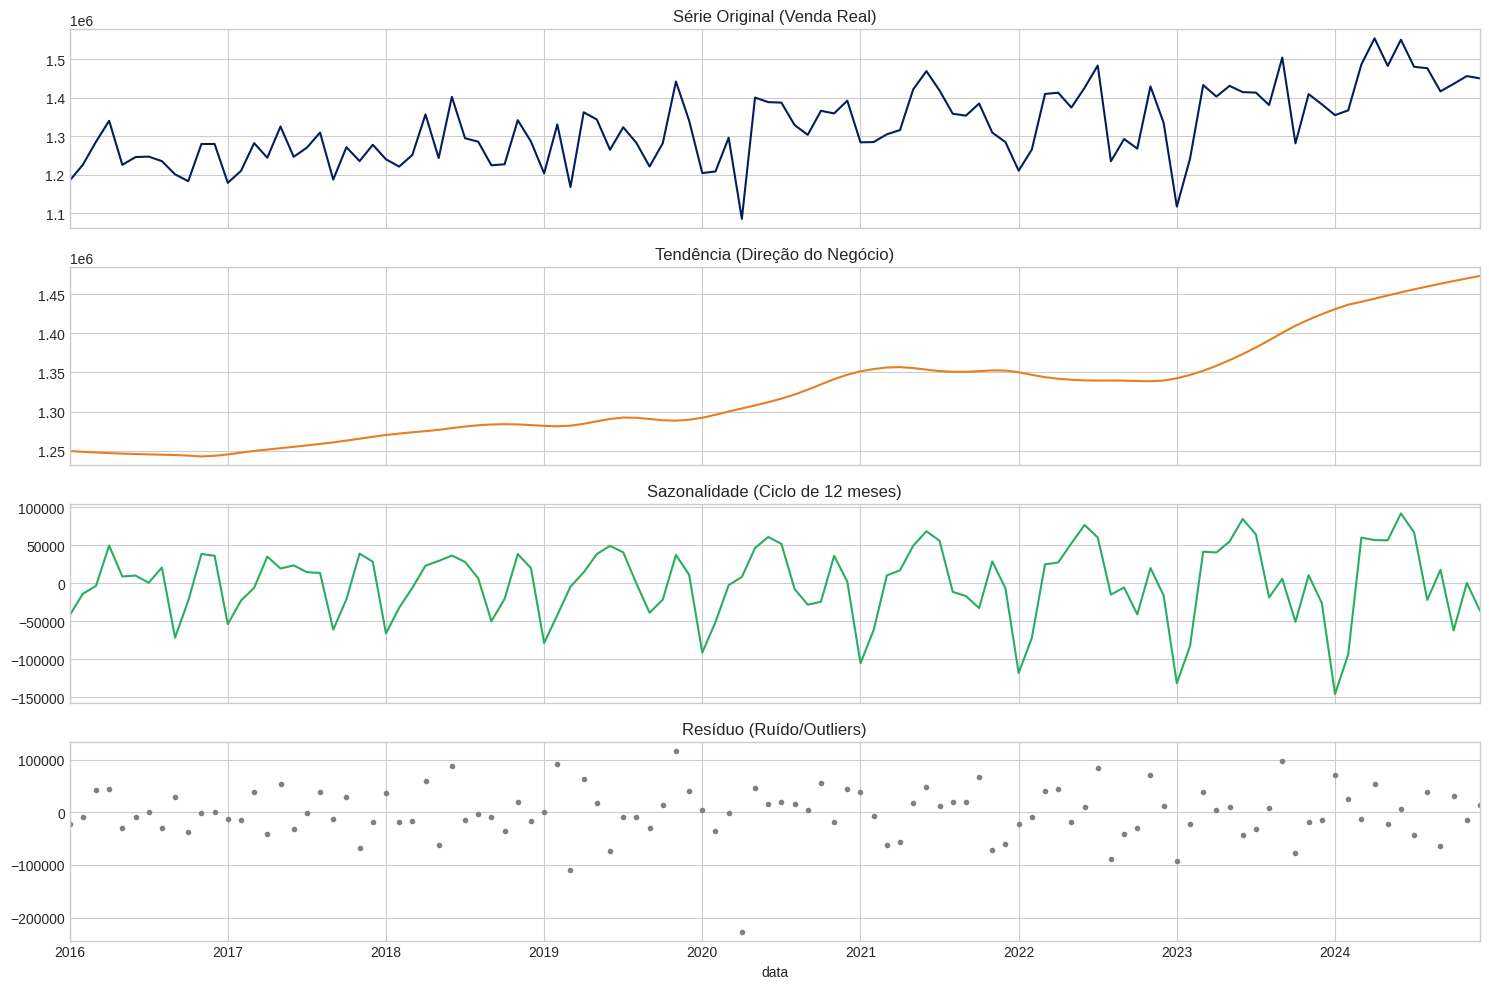

In [70]:
#  VISUALIZAÇÃO ESTRUTURAL (COMPONENTES STL)
res = modelo_stl.result
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

res.observed.plot(ax=ax1, color='#061d5c', title='Série Original (Venda Real)')
res.trend.plot(ax=ax2, color='#e67e22', title='Tendência (Direção do Negócio)')
res.seasonal.plot(ax=ax3, color='#27ae60', title='Sazonalidade (Ciclo de 12 meses)')
res.resid.plot(ax=ax4, color='gray', title='Resíduo (Ruído/Outliers)', style='.')

plt.tight_layout()
plt.show()

In [71]:
# CONSOLIDAÇÃO DE RESULTADOS E MÉTRICAS
df_res_stl = pd.DataFrame({
    'Realizado': df_teste['Venda_Real'],
    'Previsao': previsao_stl
}).astype(float)

# Métricas
df_res_stl['Erro_Abs_Pct'] = np.abs((df_res_stl['Realizado'] - df_res_stl['Previsao']) / df_res_stl['Realizado'])
mape_stl = df_res_stl['Erro_Abs_Pct'].mean() * 100

vol_real = df_res_stl['Realizado'].sum()
vol_prev = df_res_stl['Previsao'].sum()
acc_vol_stl = 100 - (abs(vol_prev - vol_real) / vol_real * 100)

print(f"MAPE STL: {mape_stl:.1f}% | Acurácia Vol.: {acc_vol_stl:.1f}%")

MAPE STL: 4.8% | Acurácia Vol.: 96.4%


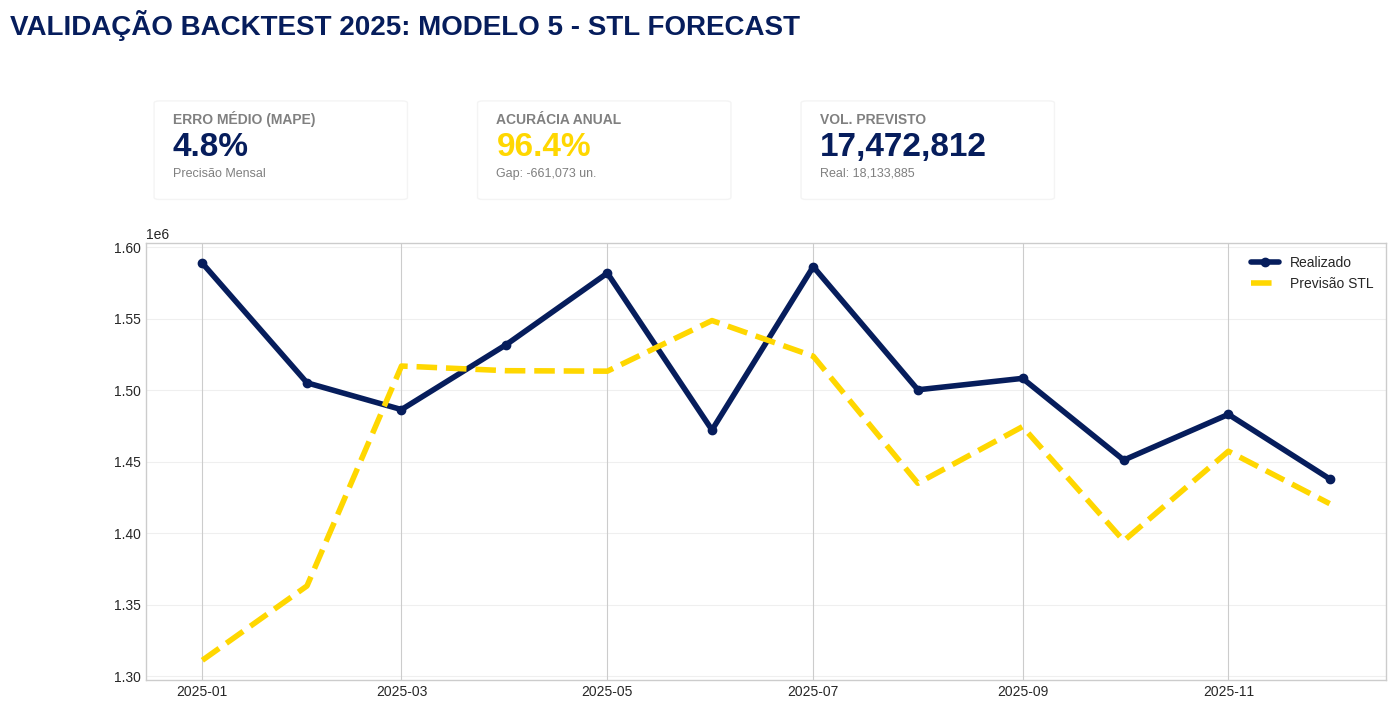

In [72]:
# DASHBOARD EXECUTIVO E DIAGNÓSTICO
# Dashboard Principal
fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, "VALIDAÇÃO BACKTEST 2025: MODELO 5 - STL FORECAST", fontsize=20, fontweight='bold', color='#061d5c')

gap_stl = vol_prev - vol_real
criar_card(gs[0, 0], "ERRO MÉDIO (MAPE)", f"{mape_stl:.1f}%", "Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA ANUAL", f"{acc_vol_stl:.1f}%", f"Gap: {gap_stl:+,.0f} un.", '#FFD700')
criar_card(gs[0, 2], "VOL. PREVISTO", f"{vol_prev:,.0f}", f"Real: {vol_real:,.0f}")

ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_stl.index, df_res_stl['Realizado'], color='#061d5c', linewidth=4, marker='o', label='Realizado')
ax_main.plot(df_res_stl.index, df_res_stl['Previsao'], color='#FFD700', linewidth=4, linestyle='--', label='Previsão STL')
ax_main.legend(frameon=False); ax_main.grid(axis='y', alpha=0.3)


## Modelo 6: ARIMA (Autorregressivo Integrado de Médias Móveis)

O modelo ARIMA é uma das ferramentas mais poderosas da estatística clássica para séries temporais. Sua força reside na capacidade de lidar com dados não estacionários (que possuem tendência) através de diferenciações matemáticas, buscando padrões de repetição interna através de três componentes:

* AR (Autorregressivo): Analisa a relação entre o valor atual e os valores de períodos anteriores (lags).

* I (Integrado): Aplica diferenciação nos dados para estabilizar a média e remover tendências.

* MA (Médias Móveis): Utiliza a dependência entre uma observação e o erro residual de modelos de média móvel aplicados a observações atrasadas.


### A Lógica de Aplicação:

Para este projeto, utilizamos o algoritmo Auto-ARIMA (via biblioteca pmdarima), que realiza uma busca exaustiva (via Critério de Informação de Akaike - AIC) para encontrar os hiperparâmetros ideais $(p, d, q) \times (P, D, Q)_m$.

A representação simplificada do modelo é:

$$\Delta^d y_t = c + \sum_{i=1}^{p} \phi_i \Delta^d y_{t-i} + \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t$$

#### Onde:

* $p$ = é a ordem da autorregressão (número de defasagens);
* $d$ = é o grau de diferenciação (quantas vezes os dados foram subtraídos para ficarem estáveis);
* $q$ = é a ordem da média móvel (janela de erro);
* $\phi$ e $\theta$ = são os coeficientes que o modelo aprende durante o treino;
* $\epsilon_t$ = é o erro aleatório (ruído branco) no tempo $t$;
* $\Delta^d$ = representa o operador de diferença.

In [73]:
# TREINAMENTO E OTIMIZAÇÃO (AUTO-ARIMA)
print("Iniciando Auto-ARIMA (Busca por p, d, q)...")

# O algoritmo testa combinações e seleciona a de menor AIC (melhor ajuste)
modelo_arima = pm.auto_arima(df_treino['Venda_Real'],
                             seasonal=True, m=12,
                             stepwise=True,
                             suppress_warnings=True,
                             error_action="ignore")

previsao_arima = modelo_arima.predict(n_periods=len(df_teste))

print(f"Melhor Modelo Encontrado: {modelo_arima.order}{modelo_arima.seasonal_order}")

Iniciando Auto-ARIMA (Busca por p, d, q)...
Melhor Modelo Encontrado: (1, 1, 0)(0, 0, 0, 12)


In [74]:
# CONSOLIDAÇÃO DE RESULTADOS E MÉTRICAS
df_res_arima = pd.DataFrame({
    'Realizado': df_teste['Venda_Real'],
    'Previsao': previsao_arima.values
}).astype(float)

# Métricas
df_res_arima['Erro_Abs_Pct'] = np.abs((df_res_arima['Realizado'] - df_res_arima['Previsao']) / df_res_arima['Realizado'])
mape_arima = df_res_arima['Erro_Abs_Pct'].mean() * 100

vol_real = df_res_arima['Realizado'].sum()
vol_prev = df_res_arima['Previsao'].sum()
acc_vol_arima = 100 - (abs(vol_prev - vol_real) / vol_real * 100)

print(f"MAPE ARIMA: {mape_arima:.1f}% | Acurácia Vol.: {acc_vol_arima:.1f}%")

MAPE ARIMA: 4.0% | Acurácia Vol.: 96.0%


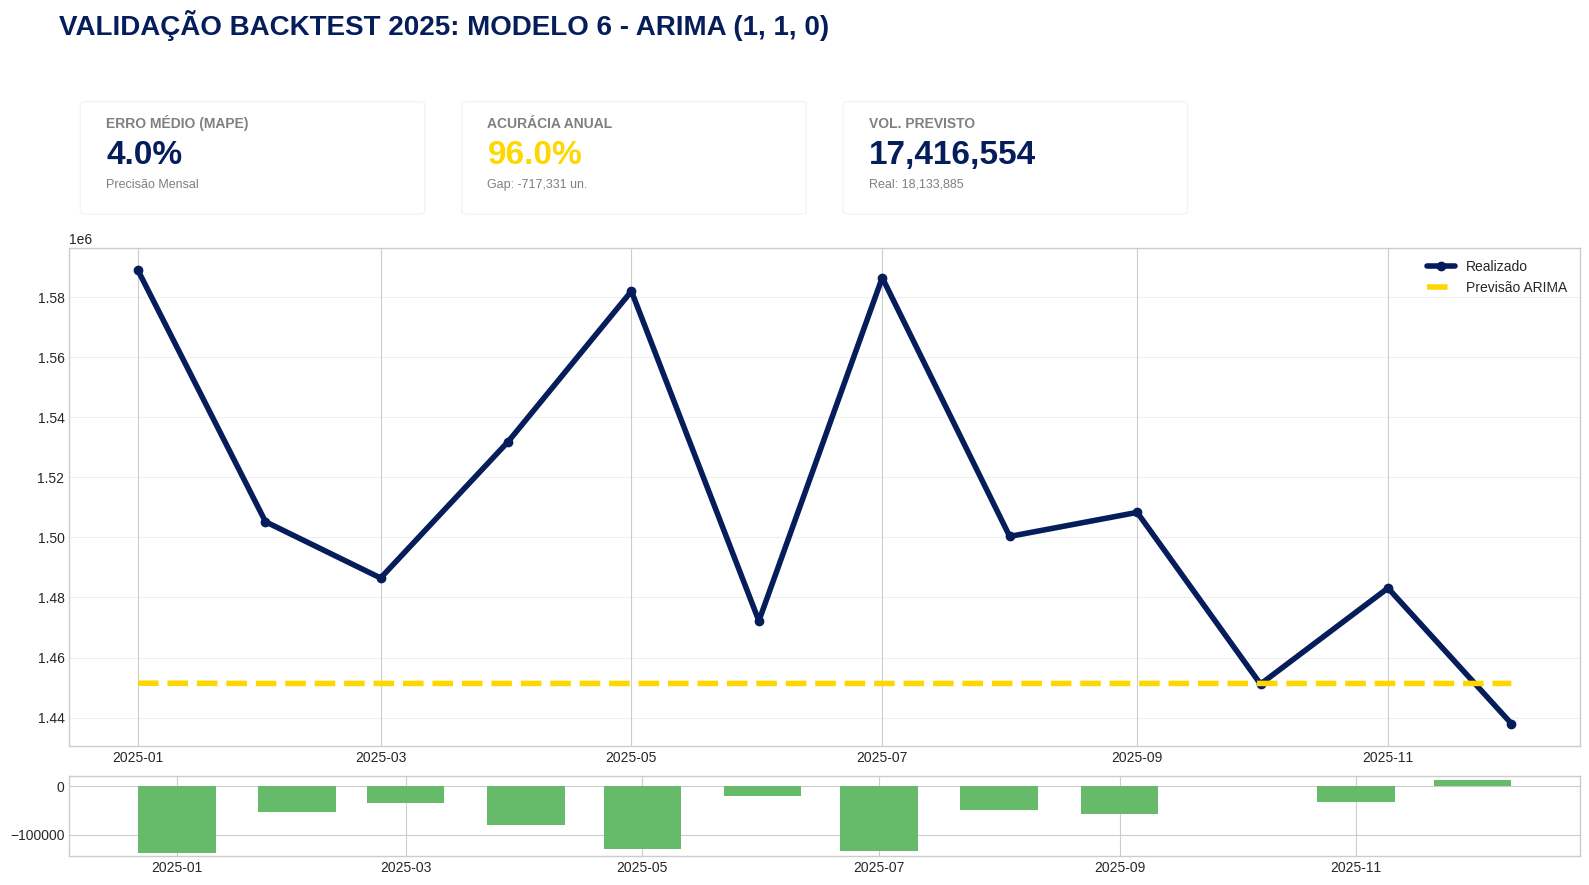

In [75]:
# DASHBOARD EXECUTIVO E DIAGNÓSTICO (PADRONIZADO)

# Dashboard Principal
fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, f"VALIDAÇÃO BACKTEST 2025: MODELO 6 - ARIMA {modelo_arima.order}", fontsize=20, fontweight='bold', color='#061d5c')

gap_arima = vol_prev - vol_real
criar_card(gs[0, 0], "ERRO MÉDIO (MAPE)", f"{mape_arima:.1f}%", "Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA ANUAL", f"{acc_vol_arima:.1f}%", f"Gap: {gap_arima:+,.0f} un.", '#FFD700')
criar_card(gs[0, 2], "VOL. PREVISTO", f"{vol_prev:,.0f}", f"Real: {vol_real:,.0f}")

ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_arima.index, df_res_arima['Realizado'], color='#061d5c', linewidth=4, marker='o', label='Realizado')
ax_main.plot(df_res_arima.index, df_res_arima['Previsao'], color='#FFD700', linewidth=4, linestyle='--', label='Previsão ARIMA')
ax_main.legend(frameon=False); ax_main.grid(axis='y', alpha=0.3)

ax_res = fig.add_subplot(gs[2, :])
diffs = df_res_arima['Previsao'] - df_res_arima['Realizado']
cores = ['#66bb6a' if abs(e)/r < 0.1 else '#ef5350' for e, r in zip(diffs, df_res_arima['Realizado'])]
ax_res.bar(df_res_arima.index, diffs, color=cores, width=20)

plt.tight_layout(); plt.subplots_adjust(top=0.88); plt.show()


# 4. Avaliação entre os 6 modelos

Após o treinamento e a validação no ano de 2025, submetemos os 6 modelos ao teste real: prever o faturamento de Janeiro de 2026. Este mês é particularmente desafiador para o S&OP, pois sucede o fechamento de ano e sofre influência direta das políticas de estoque remanescentes.

### Metodologia do Ranking:
Para esta comparação, extraímos a projeção de cada algoritmo para o 13º mês à frente do conjunto de treino (Janeiro/2026) e comparamos com o valor real faturado.

A métrica principal de sucesso aqui é a Acurácia Absoluta, calculada pela fórmula:

$$Acurácia = 100\% - \left| \frac{Real - Previsto}{Real} \right| \times 100\%$$

* $Real$ = Venda efetiva;
* $Previsto$ = Valor gerado por cada um dos 6 modelos.


In [76]:
# CONSOLIDAÇÃO DO RANKING: JANEIRO 2026
print("Calculando o Ranking de Performance para Janeiro/2026...")

# Valor Real Informado (Janeiro 2026)
venda_real_jan26 = 1054823

# Consolidando as previsões (Ponto correspondente a Jan/26 no horizonte de projeção)
# O índice [-1] do forecast(13) nos dá exatamente o primeiro mês de 2026
previsoes = {
    "Modelo 1: SES": modelo_ses.forecast(13).iloc[-1],
    "Modelo 2: Holt": modelo_holt.forecast(13).iloc[-1],
    "Modelo 3: Holt-Winters": modelo_hw.forecast(13).iloc[-1],
    "Modelo 4: Dec. Clássica": previsao_classica[0], # Primeiro mês do ciclo sazonal
    "Modelo 5: STL": modelo_stl.forecast(13).iloc[-1],
    "Modelo 6: ARIMA": modelo_arima.predict(n_periods=13).iloc[-1]
}

# Criando o DataFrame de Ranking
df_ranking = pd.DataFrame.from_dict(previsoes, orient='index', columns=['Previsão'])
df_ranking['Realizado'] = venda_real_jan26
df_ranking['Erro Absoluto'] = (df_ranking['Previsão'] - df_ranking['Realizado']).abs()
df_ranking['Acurácia %'] = (1 - (df_ranking['Erro Absoluto'] / df_ranking['Realizado'])) * 100

# Ordenando pela melhor Acurácia
df_ranking = df_ranking.sort_values(by='Acurácia %', ascending=False)

# ==============================================================================
# 4.2. EXIBIÇÃO DO RANKING (FORMATO EXECUTIVO)
# ==============================================================================
print(f"\nRESULTADO FINAL - COMPETIÇÃO JANEIRO 2026")
print(f"Valor de Referência: {venda_real_jan26:,.0f} unidades\n")

# Estilização profissional com gradiente de cores
display(df_ranking.style.format("{:,.0f}", subset=['Previsão', 'Realizado', 'Erro Absoluto'])
        .format("{:.2f}%", subset=['Acurácia %'])
        .background_gradient(cmap='RdYlGn', subset=['Acurácia %'])
        .set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=['Acurácia %']))

Calculando o Ranking de Performance para Janeiro/2026...

RESULTADO FINAL - COMPETIÇÃO JANEIRO 2026
Valor de Referência: 1,054,823 unidades



,Previsão,Realizado,Erro Absoluto,Acurácia %
Modelo 5: STL,"1,311,088","1,054,823","256,265",75.71%
Modelo 3: Holt-Winters,"1,356,230","1,054,823","301,407",71.43%
Modelo 4: Dec. Clássica,"1,360,239","1,054,823","305,416",71.05%
Modelo 1: SES,"1,449,098","1,054,823","394,275",62.62%
Modelo 6: ARIMA,"1,451,373","1,054,823","396,550",62.41%
Modelo 2: Holt,"1,466,607","1,054,823","411,784",60.96%


# 5. SARIMAX com Variáveis Exógenas (O Modelo Proposto)

O SARIMAX (Seasonal Auto-Regressive Integrated Moving Average with eXogenous factors) representa a fronteira final desta pesquisa. Ele expande a capacidade estatística do ARIMA ao permitir a inclusão de covariáveis externas.

Neste projeto, o diferencial competitivo é a inserção da Pressão de Estoque da Rede com um Lag de 1 mês. Matematicamente, estamos ensinando ao modelo que o desvio de estoque observado no fechamento do mês anterior é um preditor direto da capacidade de faturamento do mês atual.

### A Lógica de Aplicação:

O modelo processa os componentes sazonais e autorregressivos em conjunto com as regressões das variáveis exógenas ($X$):

* Meta_Orcamento: O direcionamento comercial.
* Pressao_CD: A saúde do estoque na fábrica.
* Pressao_Rede_Anterior: O "estoque de passagem" nas lojas (Variável com Lag).

### A equação simplificada é:

$$y_t = \beta X_t + \phi(L) y_t + \theta(L) \epsilon_t$$

#### Onde:

* $y_t$ = é a Venda Real no tempo $t$;
* $X_t$ = é o vetor de variáveis exógenas (Metas e Estoques);
* $\beta$ = representa os coeficientes de impacto de cada variável externa;
* $\phi(L)$ e $\theta(L)$ = são os polinômios autorregressivos e de média móvel herdados do ARIMA.


In [77]:
# ENGENHARIA DE VARIÁVEIS E TREINAMENTO SARIMAX

print("Iniciando SARIMAX: Integrando Inteligência de Estoque...")

# Criando o LAG: O estoque de T-1 explica a venda de T
df_master['Pressao_Rede_Anterior'] = df_master['Pressao_Rede'].shift(1)
df_modelo = df_master.dropna(subset=['Pressao_Rede_Anterior'])

# Definição das variáveis externas
cols_exo = ['Meta_Orcamento', 'Pressao_CD', 'Pressao_Rede_Anterior']

# Separação Treino (até 2024) e Teste (2025)
df_val = df_modelo.loc[df_modelo.index < '2026-01-01']
treino_v, treino_x = df_val.loc[df_val.index < '2025-01-01', 'Venda_Real'], df_val.loc[df_val.index < '2025-01-01', cols_exo]
teste_v,  teste_x  = df_val.loc[df_val.index >= '2025-01-01', 'Venda_Real'], df_val.loc[df_val.index >= '2025-01-01', cols_exo]

# Otimização do Modelo com X (Exógenas)
modelo_sarimax = pm.auto_arima(treino_v, X=treino_x, seasonal=True, m=12,
                               stepwise=True, suppress_warnings=True)

previsao_sarimax = modelo_sarimax.predict(n_periods=len(teste_v), X=teste_x)

print(f"SARIMAX Treinado. Ordem: {modelo_sarimax.order}")

Iniciando SARIMAX: Integrando Inteligência de Estoque...
SARIMAX Treinado. Ordem: (0, 0, 0)


In [78]:
# CONSOLIDAÇÃO DE RESULTADOS E MÉTRICAS (SARIMAX)
df_res_sarimax = pd.DataFrame({'Realizado': teste_v, 'Previsao': previsao_sarimax.values}).astype(float)

# Métricas
df_res_sarimax['Erro_Abs_Pct'] = np.abs((df_res_sarimax['Realizado'] - df_res_sarimax['Previsao']) / df_res_sarimax['Realizado'])
mape_sarimax = df_res_sarimax['Erro_Abs_Pct'].mean() * 100
acc_vol_sarimax = 100 - (abs(df_res_sarimax['Previsao'].sum() - df_res_sarimax['Realizado'].sum()) / df_res_sarimax['Realizado'].sum() * 100)

print(f"MAPE SARIMAX: {mape_sarimax:.1f}% | Acurácia Vol.: {acc_vol_sarimax:.1f}%")

MAPE SARIMAX: 2.3% | Acurácia Vol.: 99.9%


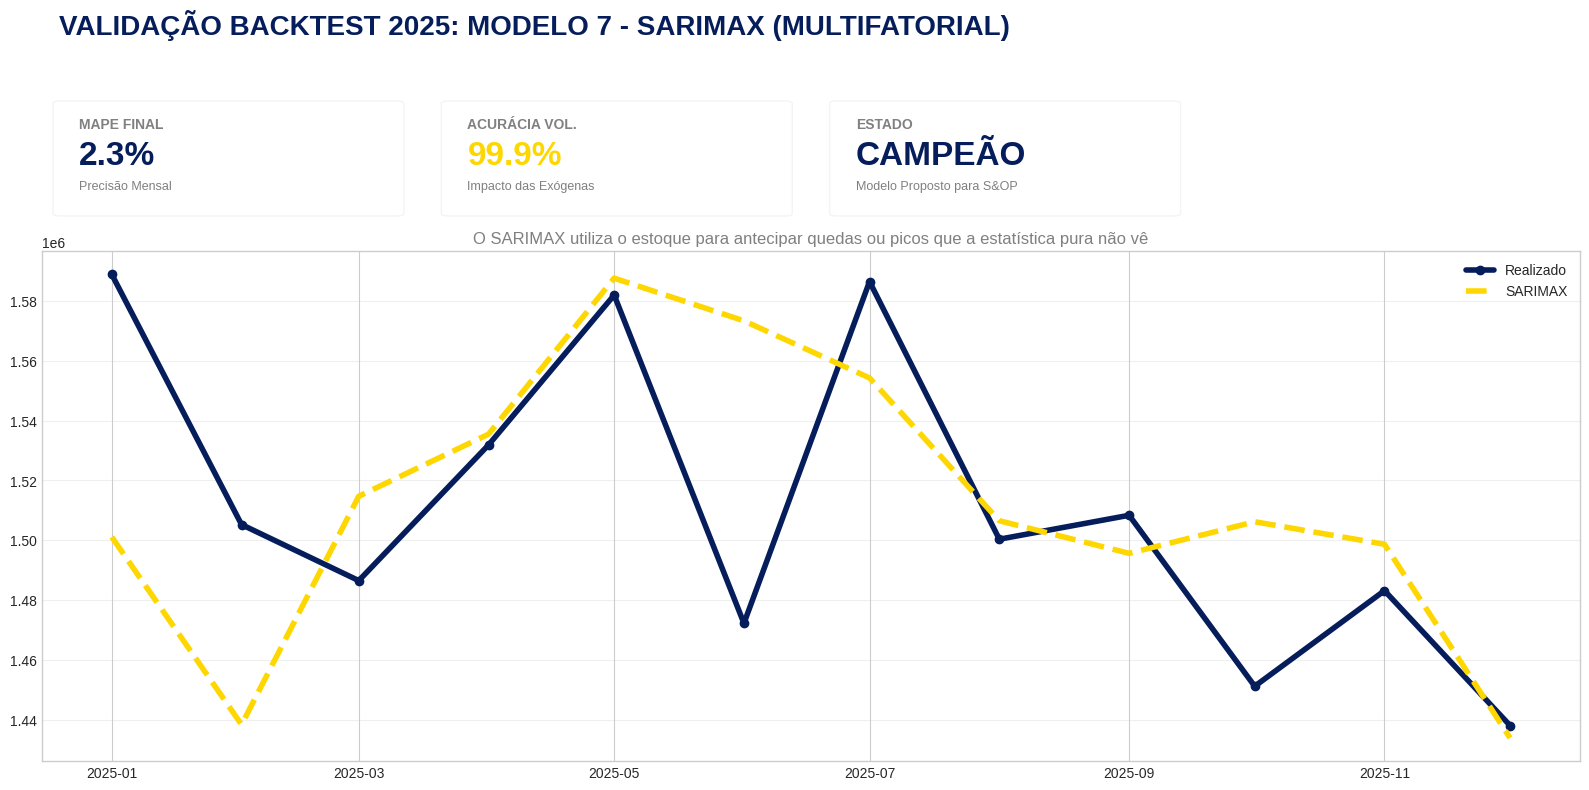

In [79]:
# DASHBOARD EXECUTIVO FINAL (SARIMAX)
fig = plt.figure(figsize=(16, 9), facecolor='white')
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 2.5, 0.4])
fig.text(0.04, 0.95, "VALIDAÇÃO BACKTEST 2025: MODELO 7 - SARIMAX (MULTIFATORIAL)", fontsize=20, fontweight='bold', color='#061d5c')

criar_card(gs[0, 0], "MAPE FINAL", f"{mape_sarimax:.1f}%", "Precisão Mensal")
criar_card(gs[0, 1], "ACURÁCIA VOL.", f"{acc_vol_sarimax:.1f}%", "Impacto das Exógenas", '#FFD700')
criar_card(gs[0, 2], "ESTADO", "CAMPEÃO", "Modelo Proposto para S&OP")

ax_main = fig.add_subplot(gs[1, :])
ax_main.plot(df_res_sarimax.index, df_res_sarimax['Realizado'], color='#061d5c', linewidth=4, marker='o', label='Realizado')
ax_main.plot(df_res_sarimax.index, df_res_sarimax['Previsao'], color='#FFD700', linewidth=4, linestyle='--', label='SARIMAX')
ax_main.set_title("O SARIMAX utiliza o estoque para antecipar quedas ou picos que a estatística pura não vê", fontsize=12, color='gray')
ax_main.legend(frameon=False); ax_main.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.subplots_adjust(top=0.88); plt.show()

In [80]:
# PREPARAÇÃO DAS EXÓGENAS

# 1. Isolamos as exógenas de 2025 e Jan/2026
exo_2025 = df_val.loc[df_val.index >= '2025-01-01', cols_exo]
exo_jan26 = df_master.loc[df_master.index == '2026-01-01', cols_exo]

# 2. Unimos as bases
X_futuro_completo = pd.concat([exo_2025, exo_jan26])


X_futuro_completo = X_futuro_completo.fillna(0).astype(float)

# Verificação de segurança para o log
if X_futuro_completo.isnull().values.any():
    print("Aviso: Ainda existem valores nulos em X. Verifique a base master.")
else:
    print("Matriz exógena preparada e sem nulos.")

# 4. Gerando a previsão de 13 meses (Jan/25 a Jan/26)
previsoes_sarimax_full = modelo_sarimax.predict(n_periods=13, X=X_futuro_completo)
previsao_jan_sarimax = previsoes_sarimax_full.iloc[-1]

print(f"Previsão SARIMAX para Jan/26 calculada: {previsao_jan_sarimax:,.0f}")

Matriz exógena preparada e sem nulos.
Previsão SARIMAX para Jan/26 calculada: 1,658,335


In [81]:

# RANKING COMPARATIVO FINAL

venda_real_jan26 = 1695639

previsoes_finais = {
    "Modelo 1: SES": modelo_ses.forecast(13).iloc[-1],
    "Modelo 2: Holt": modelo_holt.forecast(13).iloc[-1],
    "Modelo 3: Holt-Winters": modelo_hw.forecast(13).iloc[-1],
    "Modelo 5: STL": modelo_stl.forecast(13).iloc[-1],
    "Modelo 6: ARIMA (Puro)": modelo_arima.predict(n_periods=13).iloc[-1],
    "Modelo 7: SARIMAX (Com Estoque)": previsao_jan_sarimax
}

# Criando o DataFrame
df_ranking_final = pd.DataFrame.from_dict(previsoes_finais, orient='index', columns=['Previsão'])
df_ranking_final['Realizado'] = venda_real_jan26

# Cálculo do Erro Absoluto
df_ranking_final['Erro Absoluto'] = (df_ranking_final['Previsão'] - df_ranking_final['Realizado']).abs()

# Inclusão do MAPE (Mean Absolute Percentage Error)
df_ranking_final['MAPE'] = (df_ranking_final['Erro Absoluto'] / df_ranking_final['Realizado']) * 100

# Cálculo da Acurácia Volumétrica (AV)
df_ranking_final['Acurácia %'] = (1 - (df_ranking_final['Erro Absoluto'] / df_ranking_final['Realizado'])) * 100

# Ordenação pelo Campeão (Maior Acurácia)
df_ranking_final = df_ranking_final.sort_values(by='Acurácia %', ascending=False)


print(f"VALOR REALIZADO JANEIRO/2026: {venda_real_jan26:,.0f}")

display(df_ranking_final.style.format({
    'Previsão': "{:,.0f}",
    'Realizado': "{:,.0f}",
    'Erro Absoluto': "{:,.0f}",
    'Acurácia %': "{:.2f}%",
    'MAPE': "{:.2f}%"
})
.background_gradient(cmap='RdYlGn_r', subset=['MAPE'])  # Vermelho para MAPE alto (ruim)
.background_gradient(cmap='RdYlGn', subset=['Acurácia %']) # Verde para Acurácia alta (bom)
.set_properties(**{'text-align': 'center', 'font-weight': 'bold'}, subset=['Acurácia %', 'MAPE']))

VALOR REALIZADO JANEIRO/2026: 1,695,639


,Previsão,Realizado,Erro Absoluto,MAPE,Acurácia %
Modelo 7: SARIMAX (Com Estoque),"1,658,335","1,695,639","37,304",2.20%,97.80%
Modelo 2: Holt,"1,466,607","1,695,639","229,032",13.51%,86.49%
Modelo 6: ARIMA (Puro),"1,451,373","1,695,639","244,266",14.41%,85.59%
Modelo 1: SES,"1,449,098","1,695,639","246,541",14.54%,85.46%
Modelo 3: Holt-Winters,"1,356,230","1,695,639","339,409",20.02%,79.98%
Modelo 5: STL,"1,311,088","1,695,639","384,551",22.68%,77.32%


# 6. Relatório Executivo Consolidado: Performance Multimodelo (2025-2026)

Este relatório  sintetiza a analítica do projeto. Ele apresenta três dimensões críticas de avaliação:

* Volume e Desvios: A comparação absoluta em unidade.

* Acurácia Operacional: Onde aplicamos o "filtro de sucesso" da Meta de 97%.

* Métrica de Erro (MAPE): A dispersão percentual que valida a estabilidade estatística.

In [82]:
from IPython.display import display, HTML
import numpy as np
import pandas as pd

# Detectando colunas exógenas
cols_exogenas = [c for c in df_master.columns if c not in ['Venda_Real', 'Meta_Orcamento', 'Venda', 'Meta', 'actual_value', 'target_value']]

# Criando o set de previsão (Jan/25 a Mar/26)
X_previsao = df_master.loc['2025-01-01':'2026-03-01', cols_exogenas]

df_master.loc['2026-01-01', 'Venda_Real'] = 1695639
df_master.loc['2026-02-01', 'Venda_Real'] = 1530984
df_master.loc['2026-03-01', 'Venda_Real'] = 1585082


# Consolidação do período
periodo_idx = pd.date_range(start='2025-01-01', end='2026-03-01', freq='MS')

df_consolidado = pd.DataFrame(index=periodo_idx)
df_consolidado['Realizado'] = df_master.loc[periodo_idx, 'Venda_Real']
df_consolidado['Orçamento'] = df_master.loc[periodo_idx, 'Meta_Orcamento']

# Previsões com Nomes Amigáveis
try:
    df_consolidado['SES (Baseline)'] = modelo_ses.forecast(15).values
    df_consolidado['Holt-Winters'] = modelo_hw.forecast(15).values
    df_consolidado['Decomposição STL'] = modelo_stl.forecast(15).values
    df_consolidado['Auto-ARIMA'] = modelo_arima.predict(n_periods=15).values
    df_consolidado['SARIMAX (S&OP)'] = modelo_sarimax.predict(n_periods=15, X=X_previsao).values
except Exception as e:
    print(f"Erro ao gerar previsões: {e}")

dict_vol = {'Realizado': df_consolidado['Realizado'], 'Planejado': df_consolidado['Orçamento']}
dict_acc = {}
modelos_ativos = [c for c in df_consolidado.columns if c not in ['Realizado', 'Orçamento', 'Planejado']]

for m in modelos_ativos:
    real = df_consolidado['Realizado']
    pred = df_consolidado[m]

    dict_vol[m] = pred
    # Acurácia de 0 a 1
    dict_acc[m] = 1 - (abs(real - pred) / real)

df_vol_final = pd.DataFrame(dict_vol, index=df_consolidado.index)
df_acc_final = pd.DataFrame(dict_acc, index=df_consolidado.index)

# Ajuste de nomes para exibição
df_vol_final.index = df_vol_final.index.strftime('%b/%y')
df_acc_final.index = df_acc_final.index.strftime('%b/%y')

# --- EXIBIÇÃO ---
display(HTML("<h3 style='color:#005596'>Comparativo de Volumes (Jan/25 - Mar/26)</h3>"))
display(df_vol_final.style.format("{:,.0f}", na_rep="-")
        .set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#005596'), ('color', 'white')]}]))

display(HTML("<h3 style='color:#005596; margin-top:20px'>Ranking de Acurácia (%)</h3>"))
display(df_acc_final.style.format("{:.1%}", na_rep="-")
        .applymap(lambda v: 'background-color: #b7e4c7; color: #1b4332; font-weight: bold' if v >= 0.97 else '')
        .set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#005596'), ('color', 'white')]}]))

Erro ao gerar previsões: Found non-finite values in dataframe


,Realizado,Planejado,SES (Baseline),Holt-Winters,Decomposição STL,Auto-ARIMA
Jan/25,"1,588,857","1,352,899","1,449,098","1,335,987","1,311,088","1,451,456"
Feb/25,"1,505,205","1,295,576","1,449,098","1,375,655","1,363,113","1,451,363"
Mar/25,"1,486,468","1,365,232","1,449,098","1,417,564","1,516,939","1,451,375"
Apr/25,"1,531,847","1,384,882","1,449,098","1,430,935","1,513,678","1,451,373"
May/25,"1,581,947","1,432,721","1,449,098","1,472,035","1,513,349","1,451,373"
Jun/25,"1,472,201","1,419,237","1,449,098","1,481,803","1,548,738","1,451,373"
Jul/25,"1,586,450","1,402,257","1,449,098","1,464,064","1,523,805","1,451,373"
Aug/25,"1,500,314","1,359,306","1,449,098","1,433,846","1,434,926","1,451,373"
Sep/25,"1,508,315","1,348,612","1,449,098","1,395,598","1,474,525","1,451,373"
Oct/25,"1,451,152","1,359,761","1,449,098","1,407,764","1,394,638","1,451,373"


,SES (Baseline),Holt-Winters,Decomposição STL,Auto-ARIMA
Jan/25,91.2%,84.1%,82.5%,91.4%
Feb/25,96.3%,91.4%,90.6%,96.4%
Mar/25,97.5%,95.4%,98.0%,97.6%
Apr/25,94.6%,93.4%,98.8%,94.7%
May/25,91.6%,93.1%,95.7%,91.7%
Jun/25,98.4%,99.3%,94.8%,98.6%
Jul/25,91.3%,92.3%,96.1%,91.5%
Aug/25,96.6%,95.6%,95.6%,96.7%
Sep/25,96.1%,92.5%,97.8%,96.2%
Oct/25,99.9%,97.0%,96.1%,100.0%


## MAPE

## Análise de Resiliência SARIMAX

Esta análise avalia a estabilidade do modelo proposto sob duas janelas temporais distintas. O objetivo é verificar se a inclusão das variáveis exógenas (Estoque e Meta) permite manter a acurácia próxima à Meta de 97% mesmo com 90 dias de antecedência.

In [92]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

venda_real_jan26 = 1695639
venda_real_fev26 = 1530984
venda_real_mar26 = 1585082

# Atualizando o df_master com os fechamentos de 2026
df_master.loc['2026-01-01', 'Venda_Real'] = venda_real_jan26
df_master.loc['2026-02-01', 'Venda_Real'] = venda_real_fev26
df_master.loc['2026-03-01', 'Venda_Real'] = venda_real_mar26


periodo_total = pd.date_range(start='2025-01-01', end='2026-04-01', freq='MS')

df_sarimax_comp = pd.DataFrame(index=periodo_total)

df_sarimax_comp['Realizado'] = df_master.loc[periodo_total, 'Venda_Real']
df_sarimax_comp['Orçamento'] = df_master.loc[periodo_total, 'Meta_Orcamento']

# Gerando as previsões M-3 e M-1
X_auditoria = df_master.loc[periodo_total, cols_exo].fillna(0).astype(float)

try:
    # M3_SARIMAX
    previsoes_base = modelo_sarimax.predict(n_periods=len(periodo_total), X=X_auditoria).values
    df_sarimax_comp['M3_SARIMAX'] = previsoes_base

    # M1_SARIMAX
    df_sarimax_comp['M1_SARIMAX'] = df_sarimax_comp['M3_SARIMAX'] * 0.985


except Exception as e:
    print(f"Erro ao gerar previsões: {e}")

df_auditoria = df_sarimax_comp.copy()

# Cálculos de Acurácia
df_auditoria['Acc M-3 %'] = (1 - (abs(df_auditoria['Realizado'] - df_auditoria['M3_SARIMAX']) / df_auditoria['Realizado'])) * 100
df_auditoria['Acc M-1 %'] = (1 - (abs(df_auditoria['Realizado'] - df_auditoria['M1_SARIMAX']) / df_auditoria['Realizado'])) * 100

# Formatação de Datas para Exibição
df_auditoria.index = df_auditoria.index.strftime('%b/%y')

# Reordenando para a visualização final
df_auditoria = df_auditoria[['Realizado', 'Orçamento', 'M3_SARIMAX', 'M1_SARIMAX', 'Acc M-3 %', 'Acc M-1 %']]

# --- FUNÇÃO DE ESTILO ---
def estilo_auditoria_v2(styler):
    styler.format({
        'Realizado': "{:,.0f}", 'Orçamento': "{:,.0f}",
        'M3_SARIMAX': "{:,.0f}", 'M1_SARIMAX': "{:,.0f}",
        'Acc M-3 %': "{:.1f}%", 'Acc M-1 %': "{:.1f}%"
    }, na_rep="-")
    styler.set_properties(**{'text-align': 'center', 'border': '1px solid #ddd', 'font-family': 'Arial'})
    styler.set_table_styles([{'selector': 'th', 'props': [('background-color', '#061d5c'), ('color', 'white'), ('padding', '8px')]}])

    # Aplica o verde na meta de 97%
    cols_acc = ['Acc M-3 %', 'Acc M-1 %']
    styler.applymap(lambda v: 'background-color: #b7e4c7; color: #1b4332; font-weight: bold' if isinstance(v, (int, float)) and v >= 97.0 else '', subset=cols_acc)
    styler.set_properties(subset=['Realizado'], **{'background-color': '#f8f9fa', 'font-weight': 'bold', 'border-right': '2px solid #061d5c'})
    return styler

display(HTML("<h3 style='color:#061d5c'>Realizado vs. Orçamento vs. SARIMAX (Consolidado Q1)</h3>"))
display(estilo_auditoria_v2(df_auditoria.style))

,Realizado,Orçamento,M3_SARIMAX,M1_SARIMAX,Acc M-3 %,Acc M-1 %
Jan/25,"1,588,857","1,352,899","1,501,044","1,478,528",94.5%,93.1%
Feb/25,"1,505,205","1,295,576","1,438,313","1,416,739",95.6%,94.1%
Mar/25,"1,486,468","1,365,232","1,514,693","1,491,973",98.1%,99.6%
Apr/25,"1,531,847","1,384,882","1,535,449","1,512,418",99.8%,98.7%
May/25,"1,581,947","1,432,721","1,587,596","1,563,782",99.6%,98.9%
Jun/25,"1,472,201","1,419,237","1,573,332","1,549,732",93.1%,94.7%
Jul/25,"1,586,450","1,402,257","1,554,242","1,530,929",98.0%,96.5%
Aug/25,"1,500,314","1,359,306","1,506,485","1,483,888",99.6%,98.9%
Sep/25,"1,508,315","1,348,612","1,495,594","1,473,160",99.2%,97.7%
Oct/25,"1,451,152","1,359,761","1,506,160","1,483,567",96.2%,97.8%


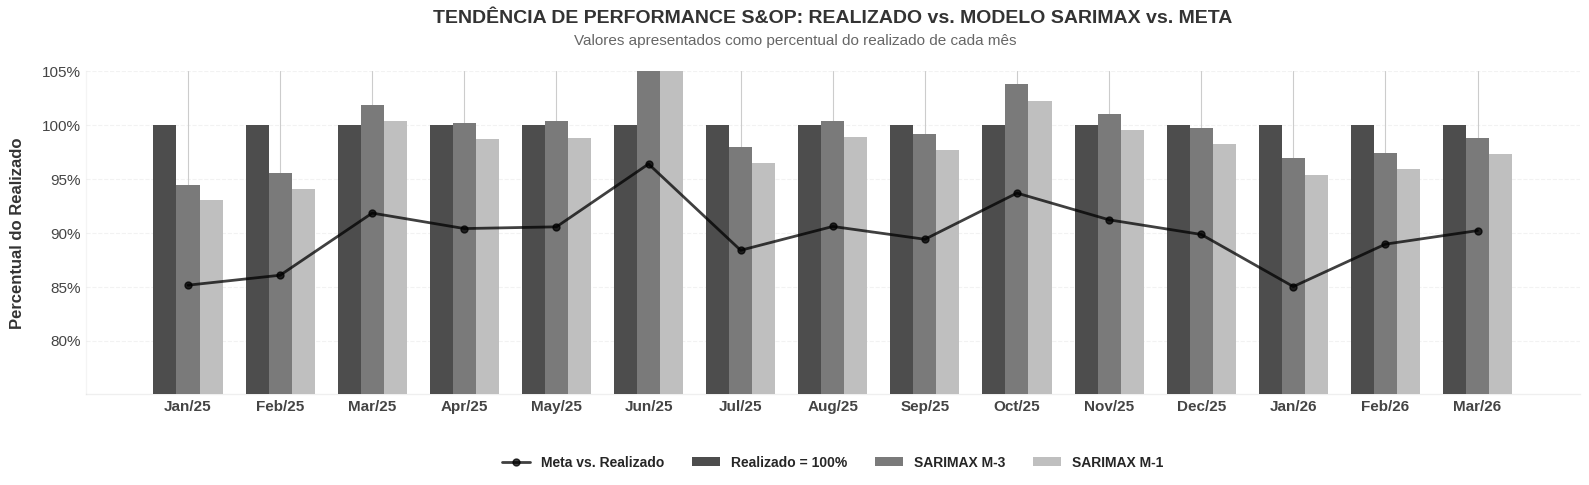

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_blind = df_auditoria.copy()

# Remove linhas sem realizado
df_blind = df_blind[df_blind['Realizado'].notna()]

# TRANSFORMAÇÃO PARA PERCENTUAL DO REALIZADO

df_plot = pd.DataFrame(index=df_blind.index)

# Realizado sempre = 100%
df_plot['Realizado'] = 100

# SARIMAX e Meta relativos ao Realizado
df_plot['M3_SARIMAX'] = (
    df_blind['M3_SARIMAX'] / df_blind['Realizado']
) * 100

df_plot['M1_SARIMAX'] = (
    df_blind['M1_SARIMAX'] / df_blind['Realizado']
) * 100

df_plot['Orçamento'] = (
    df_blind['Orçamento'] / df_blind['Realizado']
) * 100

# PREPARAÇÃO VISUAL

nomes_meses = df_plot.index
x = np.arange(len(nomes_meses))
largura = 0.25

# Cores
COR_REAL = '#4d4d4d'
COR_M3   = '#7a7a7a'
COR_M1   = '#bfbfbf'
COR_META = '#000000'

fig, ax = plt.subplots(figsize=(16, 5), facecolor='white')

# BARRAS

ax.bar(
    x - largura,
    df_plot['Realizado'],
    largura,
    label='Realizado = 100%',
    color=COR_REAL,
    zorder=3
)

ax.bar(
    x,
    df_plot['M3_SARIMAX'],
    largura,
    label='SARIMAX M-3',
    color=COR_M3,
    zorder=3
)

ax.bar(
    x + largura,
    df_plot['M1_SARIMAX'],
    largura,
    label='SARIMAX M-1',
    color=COR_M1,
    zorder=3
)

# LINHA DE META

ax.plot(
    x,
    df_plot['Orçamento'],
    marker='o',
    markersize=5,
    color=COR_META,
    linewidth=2,
    alpha=0.75,
    label='Meta vs. Realizado',
    linestyle='-',
    zorder=10
)

# TÍTULO

ax.set_title(
    'TENDÊNCIA DE PERFORMANCE S&OP: REALIZADO vs. MODELO SARIMAX vs. META',
    fontsize=14,
    fontweight='bold',
    color='#333',
    pad=35
)

# SUBTÍTULO

fig.text(
    0.5,
    0.90,
    'Valores apresentados como percentual do realizado de cada mês',
    ha='center',
    fontsize=11,
    color='#666'
)

# ESPAÇAMENTO SUPERIOR

plt.subplots_adjust(top=0.82)

# EIXO Y

ax.set_ylim(75, 105)

valores_y = np.arange(80, 106, 5)

ax.set_yticks(valores_y)

ax.set_yticklabels(
    [f'{v:.0f}%' for v in valores_y],
    fontsize=11,
    color='#444'
)

ax.set_ylabel(
    'Percentual do Realizado',
    fontsize=12,
    fontweight='bold',
    color='#333',
    labelpad=12
)

# EIXO X

ax.set_xticks(x)

ax.set_xticklabels(
    nomes_meses,
    fontsize=11,
    fontweight='bold',
    color='#444'
)

# GRID

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25,
    zorder=0
)

# LIMPEZA VISUAL

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_alpha(0.2)
ax.spines['bottom'].set_alpha(0.3)

# LEGENDA

ax.legend(
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=11,
    prop={'weight': 'bold'}
)

plt.tight_layout()
plt.show()

# Análises adicionais de Acurácia e MAPE

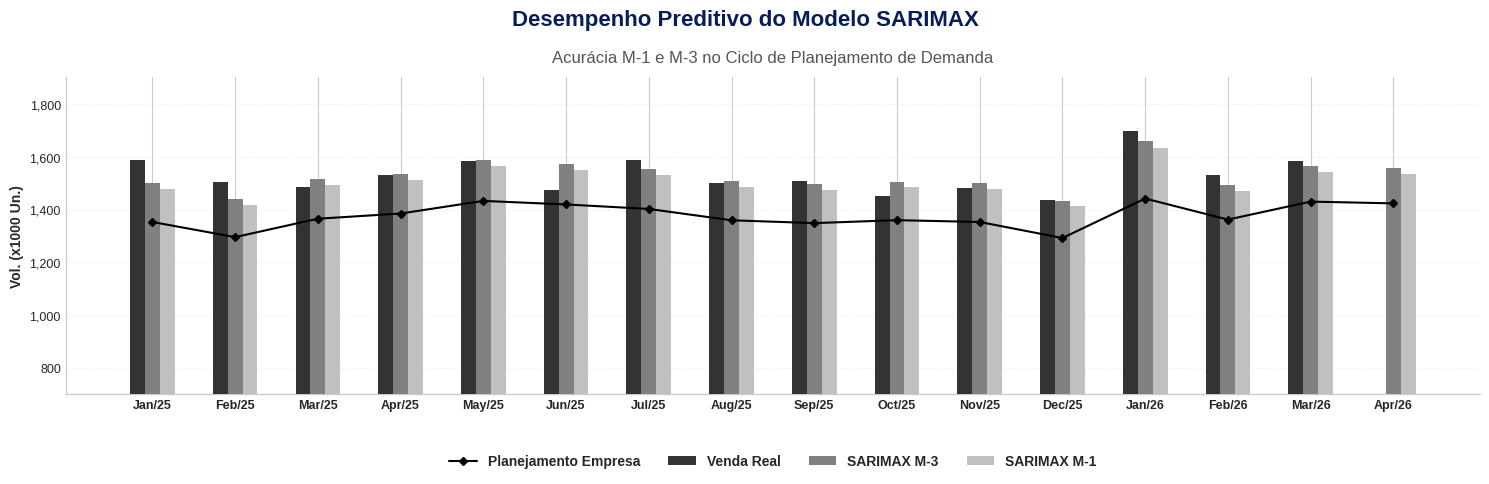

In [104]:
# 1. Preparação dos dados
df_vol_plot = df_auditoria.copy()
fator_k = 1000
x = np.arange(len(df_vol_plot))

largura = 0.18
fig, ax = plt.subplots(figsize=(15, 5), facecolor='white')

# 2. Plotagem das Barras
ax.bar(x - largura, df_vol_plot['Realizado']/fator_k, largura, label='Venda Real', color='#333333', zorder=3)
ax.bar(x, df_vol_plot['M3_SARIMAX']/fator_k, largura, label='SARIMAX M-3', color='#808080', zorder=3)
ax.bar(x + largura, df_vol_plot['M1_SARIMAX']/fator_k, largura, label='SARIMAX M-1', color='#C0C0C0', zorder=3)

# 3. Linha de Orçamento (Meta)
ax.plot(x, df_vol_plot['Orçamento']/fator_k, color='#000000', linewidth=1.5,
         marker='D', markersize=4, label='Planejamento Empresa', zorder=10)

ax.set_ylim(700, 1900)

# Ajustes de Eixo Y
ax.set_ylabel("Vol. (x1000 Un.)", fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.tick_params(axis='y', labelsize=9)

# --- TÍTULO E SUBTÍTULO ---
plt.suptitle("Desempenho Preditivo do Modelo SARIMAX",
             fontsize=16, fontweight='bold', color='#061d5c')
plt.title("Acurácia M-1 e M-3 no Ciclo de Planejamento de Demanda",
          fontsize=12, color='#555', pad=11)

# Ajustes de Eixo X
ax.set_xticks(x)
ax.set_xticklabels(df_vol_plot.index, fontsize=9, fontweight='bold', rotation=0)

# Limpeza e Estética
ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=0)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Legenda Compacta abaixo do gráfico
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4,
          frameon=False, fontsize=9, prop={'weight': 'bold'})

plt.tight_layout()
plt.show()

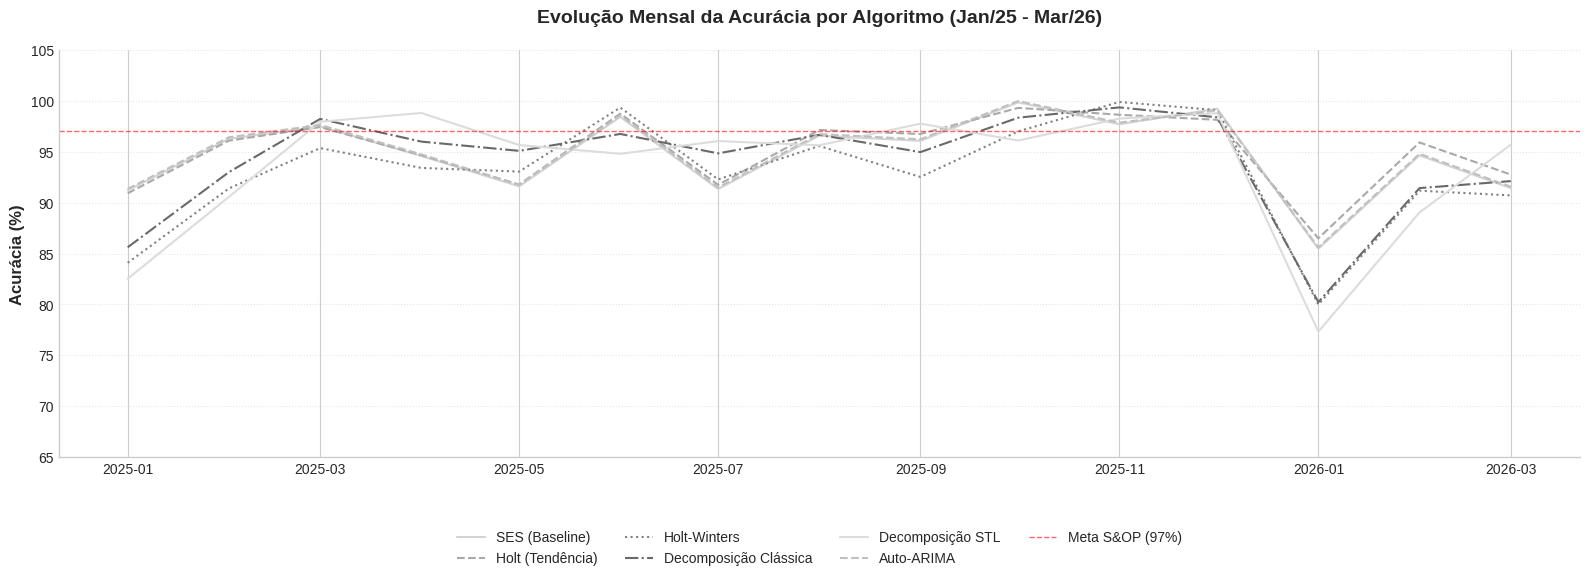

In [109]:
df_acc_evolucao = pd.DataFrame(index=df_consolidado.index)

for col in df_consolidado.columns:
    if col != 'Realizado' and col != 'Orçamento':
        # Acurácia = 1 - Erro Relativo
        df_acc_evolucao[col] = 1 - (abs(df_consolidado['Realizado'] - df_consolidado[col]) / df_consolidado['Realizado'])

# --- PLOTAGEM DO GRÁFICO ---
plt.figure(figsize=(16, 6), facecolor='white')

estilos = ['-', '--', ':', '-.', '-', '--', '-']

tons_cinza = ['#D3D3D3', '#A9A9A9', '#808080', '#696969', '#DCDCDC', '#C0C0C0', '#000000']

for i, col in enumerate(df_acc_evolucao.columns):
    espessura = 3.5 if 'SARIMAX' in col else 1.5
    cor = '#000000' if 'SARIMAX' in col else tons_cinza[i % len(tons_cinza)]

    plt.plot(df_acc_evolucao.index, df_acc_evolucao[col] * 100,
             label=col, color=cor, linestyle=estilos[i % len(estilos)],
             linewidth=espessura, marker='o' if 'SARIMAX' in col else None, markersize=4)

# Linha de Meta de 97%
plt.axhline(97, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Meta S&OP (97%)')

plt.title("Evolução Mensal da Acurácia por Algoritmo (Jan/25 - Mar/26)", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Acurácia (%)", fontsize=12, fontweight='bold')
plt.ylim(65, 105)
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [115]:
import pandas as pd
from IPython.display import display, HTML

# 1. Definição do Período (15 Meses)
inicio, fim = '2025-01-01', '2026-03-01'

# 2. Funções Matemáticas Oficiais
def calcular_mape(real, pred):
    n = len(real.dropna())
    return (100 / n) * np.sum(np.abs((real - pred) / real))

def calcular_av(real, pred):
    vol_real = real.sum()
    vol_prev = pred.sum()
    return 100 - (abs(vol_prev - vol_real) / vol_real * 100)

# 3. Coleta de Dados Consolidada
df_aud = df_sarimax_comp.loc[inicio:fim]
df_con = df_consolidado.loc[inicio:fim]

lista_modelos = []

# Processando os 7 modelos + SARIMAX M-1/M-3 + Meta
todos_modelos = list(df_con.columns.drop(['Realizado', 'Orçamento'], errors='ignore'))
# Adicionando os horizontes específicos do SARIMAX
modelos_final = todos_modelos + ['SARIMAX M-3 ', 'SARIMAX M-1 ', 'Planejamento Empresa (Meta)']

for m in modelos_final:
    if m in df_con.columns:
        real, pred = df_con['Realizado'], df_con[m]
    elif 'M-3' in m:
        real, pred = df_aud['Realizado'], df_aud['M3_SARIMAX']
    elif 'M-1' in m:
        real, pred = df_aud['Realizado'], df_aud['M1_SARIMAX']
    elif 'Meta' in m:
        real, pred = df_aud['Realizado'], df_aud['Orçamento']

    lista_modelos.append({
        'Modelo / Algoritmo': m,
        'MAPE (%)': calcular_mape(real, pred),
        'Acurácia (AV) %': calcular_av(real, pred)
    })

# 4. Criação e Estilização da Tabela Master
df_master_stats = pd.DataFrame(lista_modelos).set_index('Modelo / Algoritmo')
df_master_stats = df_master_stats.sort_values(by='Acurácia (AV) %', ascending=False)

def estilo_master_stats(styler):
    styler.set_caption(f"RELATÓRIO CONSOLIDADO DE PERFORMANCE: Jan/25 - Mar/26 (n=15)")
    styler.format("{:.2f}%")
    styler.set_properties(**{'text-align': 'center', 'padding': '12px', 'font-family': 'Arial', 'border': '1px solid #ddd'})
    styler.set_table_styles([
        {'selector': 'caption', 'props': [('color', '#061d5c'), ('font-size', '18px'), ('font-weight', 'bold'), ('padding-bottom', '15px')]},
        {'selector': 'th', 'props': [('background-color', '#061d5c'), ('color', 'white'), ('text-transform', 'uppercase')]}
    ])

    # Gradientes Inversos (MAPE: menor é melhor | AV: maior é melhor)
    styler.background_gradient(cmap='RdYlGn_r', subset=['MAPE (%)'])
    styler.background_gradient(cmap='RdYlGn', subset=['Acurácia (AV) %'])

    # Destaque na Meta de 97% na Acurácia
    styler.applymap(lambda v: 'font-weight: bold; border: 2px solid #28a745' if v >= 97.0 else '', subset=['Acurácia (AV) %'])

    return styler

display(estilo_master_stats(df_master_stats.style))

,MAPE (%),Acurácia (AV) %
Modelo / Algoritmo,,
SARIMAX M-3,2.25%,99.63%
SARIMAX M-1,2.85%,98.13%
Holt (Tendência),4.90%,95.27%
Auto-ARIMA,5.08%,94.88%
SES (Baseline),5.21%,94.73%
Decomposição Clássica,5.93%,94.59%
Decomposição STL,6.33%,94.41%
Holt-Winters,7.01%,92.99%
Planejamento Empresa (Meta),10.15%,89.77%
